# COMP4318/5318 Assignment 2: Image Classification

### Group number: 2
### SID1: 540940282 , SID2: 540791765, SID3: 520193035, SID4: 540889718

This template notebook includes code to load the  dataset and a skeleton for the main sections that should be included in the notebook. Please stick to this struture for your submitted notebook.

Please focus on making your code clear, with appropriate variable names and whitespace. Include comments and markdown text to aid the readability of your code where relevant. See the specification and marking criteria in the associated specification to guide you when completing your implementation.

## Setup and dependencies
To run this code:

Requirements: Python 3.11

Uncomment the first cell to run to install required enviroment.

The code looks for the data set at the following location relative to this notebook: `./Assignment2Data/X_test.npy`,`./Assignment2Data/X_train.npy`,`./Assignment2Data/y_test.npy`,`./Assignment2Data/y_train.npy`.

#### A Brief description of all the libraries

#### **1. Computer Vision / Image Processing**
**cv2:** OpenCV for image/video processing;<br>
**skimage.measure (block_reduce):** image downsampling;<br>

#### **2. Deep Learning / Neural Networks**
**tensorflow (tf):** deep learning framework;<br>
**keras / tensorflow.keras:** high-level neural networks API;<br>
**tensorflow.keras.Sequential:** linear stack of layers;<br>
**tensorflow.keras.layers (Conv2D, MaxPooling2D, Flatten, Dense, Dropout):** core layers for CNNs;<br>
**tensorflow.keras.optimizers (Adam):** optimizer for training models;<br>
**tensorflow.keras.regularizers:** L1/L2 weight penalties;<br>
**keras_tuner (kt):** hyperparameter tuning;<br>

#### **3. Machine Learning / Data Science**
**sklearn.model_selection (train_test_split, GridSearchCV, StratifiedKFold):** splitting datasets and hyperparameter search;<br>
**sklearn.metrics (confusion_matrix, accuracy_score, classification_report):** model evaluation;<br>
**sklearn.decomposition (PCA):** dimensionality reduction;<br>
**sklearn.svm (LinearSVC):** linear SVM classifier;<br>
**sklearn.pipeline (Pipeline):** chaining transformations and models;<br>

#### **4. Data Manipulation / Numerical Computing**
**numpy (np):** numerical computing and arrays;<br>
**pandas (pd):** data manipulation and analysis;<br>

#### **5. Visualization**
**matplotlib.pyplot (plt):** plotting;<br>
**matplotlib.ticker (mtick):** axis tick formatting;<br>
**seaborn (sns):** statistical visualization;<br>

#### **6. Utilities / Python Standard Libraries**
**time:** time-related functions;<br>
**random:** random number generation;<br>
**os:** operating system interaction;<br>
**pathlib (Path):** filesystem paths;<br>
**IPython.display (display):** rich content display in notebooks;<br>

In [2]:
"""
!pip install tensorflow==2.16.0
!pip install numpy==1.26.4
!pip install pandas==2.2.2
!pip install scikit-learn==1.5.1
!pip install matplotlib==3.9.1
!pip install seaborn==0.13.2
!pip install opencv-python
!pip install tensorflow
!pip install keras_tuner
"""

'\n!pip install tensorflow==2.16.0\n!pip install numpy==1.26.4\n!pip install pandas==2.2.2\n!pip install scikit-learn==1.5.1\n!pip install matplotlib==3.9.1\n!pip install seaborn==0.13.2\n!pip install opencv-python\n!pip install tensorflow\n!pip install keras_tuner\n'

In [3]:
## Import Libraries
# System / OS / Path handling
import os
from pathlib import Path
import time
import random
import sys

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from matplotlib.patches import Rectangle

# Image processing
import cv2
import skimage
from skimage.measure import block_reduce

# Machine Learning / Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, regularizers, mixed_precision
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

# Scikit-learn
import sklearn
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score


In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)
os.environ['PYTHONHASHSEED'] = str(42)

try:    
    tf.config.experimental.enable_op_determinism(True)
    tf.config.list_physical_devices('GPU')
except Exception:
    pass

In [5]:
# List of modules to check

print("Python version:", sys.version)
print("OS:", os.name)
print("Time module version:", time.__doc__.splitlines()[0] if hasattr(time, '__doc__') else "built-in")
print("Random module version:", random.__doc__.splitlines()[0] if hasattr(random, '__doc__') else "built-in")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("OpenCV version:", cv2.__version__)
print("Scikit-Image version:", skimage.__version__)
print("TensorFlow version:", tf.__version__)
print("Keras Tuner version:", kt.__version__)
print("Scikit-Learn version:", sklearn.__version__)
print("Python executable:", sys.executable)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

Python version: 3.11.0 | packaged by conda-forge | (main, Jan 14 2023, 12:26:40) [Clang 14.0.6 ]
OS: posix
Time module version: This module provides various functions to manipulate time values.
Random module version: Random variable generators.
NumPy version: 1.26.4
Pandas version: 2.3.3
Matplotlib version: 3.10.7
Seaborn version: 0.13.2
OpenCV version: 4.8.1
Scikit-Image version: 0.25.2
TensorFlow version: 2.16.2
Keras Tuner version: 1.4.7
Scikit-Learn version: 1.7.2
Python executable: /Users/chingyu/anaconda3/envs/tf-m4/bin/python
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data loading, exploration, and preprocessing


### 1-1 Data Loading
Code to load the dataset is provided in the following cell. Please proceed with your data exploration and preprocessing in the remainder of this section.

In [6]:
# Load the dataset training and test sets as numpy arrays
# assuming Assignment2Data folder is present in the same directory
# as the notebook
X_train = np.load('Assignment2Data/X_train.npy')
y_train = np.load('Assignment2Data/y_train.npy')
X_test = np.load('Assignment2Data/X_test.npy')
y_test = np.load('Assignment2Data/y_test.npy')

### 1-2 Data Exploration


#### Shape And Data Types

In [7]:
## Print the shapes of all the loaded np arrays
print("--- Initial Data Shapes and Types ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nData type of X_train: {X_train.dtype}")
print(f"Data type of y_train: {y_train.dtype}")
print(f"Data type of X_test: {X_test.dtype}")
print(f"Data type of y_test: {y_test.dtype}")

--- Initial Data Shapes and Types ---
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)

Data type of X_train: uint8
Data type of y_train: int64
Data type of X_test: uint8
Data type of y_test: int64


#### Quick view of data

In [8]:
# plot showing function
def plot_examples(data, n_rows=4, n_cols=10):
    """Plot a grid of MNIST examples of a specified size."""
    # Size figure depending on the size of the grid
    plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
    for row in range(n_rows):
        for col in range(n_cols):
            # Get next index of image
            index = n_cols * row + col
            # Plot the image at appropriate place in grid
            plt.subplot(n_rows, n_cols, index + 1)
            plt.imshow(data[index], cmap="binary")
            plt.axis('off')
    plt.show()

### 1. Basic Overview ###
First 5 labels of y_train: [6 9 9 4 1]
Unique of y_train: [0 1 2 3 4 5 6 7 8 9]

Quick view of X_train:
- Length of X_train[0]: 32
- Length of X_train[0][0]: 32
- Length of X_train[0][0][0]: 3
  - X_train[0][0][0]: [59 62 63]

Quick View of X_train in Visualisation


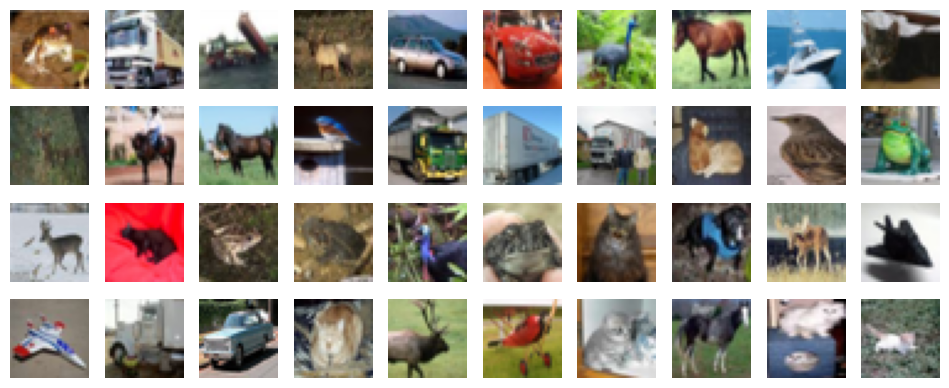

In [9]:
print("### 1. Basic Overview ###")

# Check the format of the label by looking at the first five examples
print("First 5 labels of y_train:",y_train[0:5])

# List all unique labels in the training set
unique_classes, class_counts = np.unique(y_train, return_counts=True)
print("Unique of y_train:",unique_classes)
class_names = unique_classes.tolist()

# quick view of X train
print("\nQuick view of X_train:")
print("- Length of X_train[0]:",len(X_train[0]))
print("- Length of X_train[0][0]:",len(X_train[0][0]))
print("- Length of X_train[0][0][0]:",len(X_train[0][0][0]))
print("  - X_train[0][0][0]:",X_train[0][0][0])

# quick view of X train in visualisation
print("\nQuick View of X_train in Visualisation")
plot_examples(X_train)

#### Quick View of 10 classes

### 2. Class Distribution ###


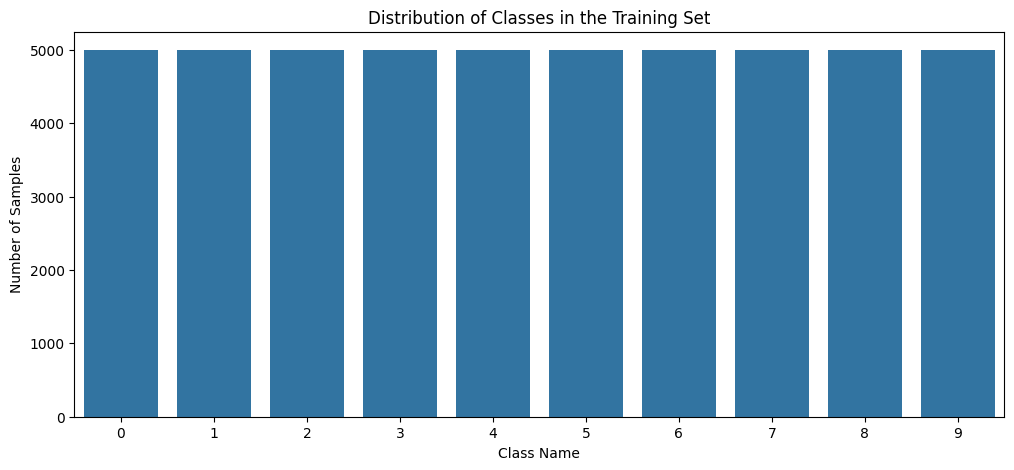

In [10]:
print("### 2. Class Distribution ###")

# Plotting the class distribution
plt.figure(figsize=(12, 5))
sns.barplot(x=[class_names[i] for i in class_names], y=class_counts)
plt.title("Distribution of Classes in the Training Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Samples")
plt.show()


#### Pixel Intensity Distribution

### 3. Pixel Intensity Distribution ###


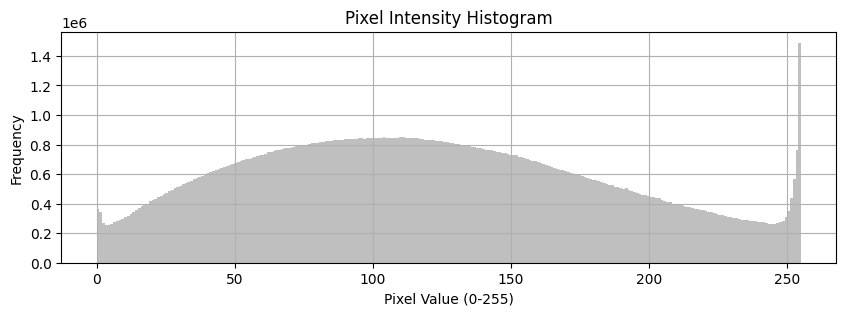

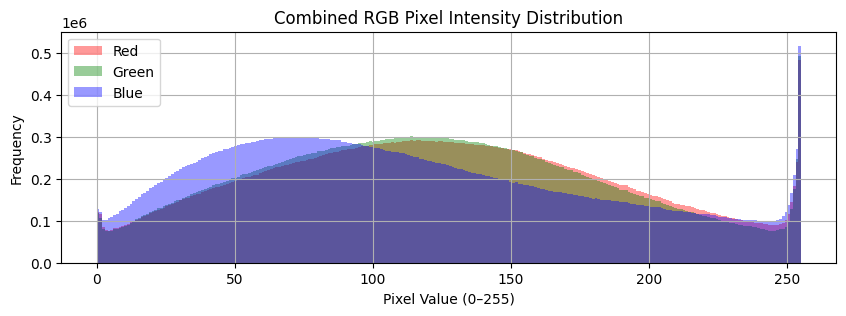

In [11]:
print("### 3. Pixel Intensity Distribution ###")

plt.figure(figsize=(10, 3))
plt.hist(X_train.flatten(), bins=256, color='gray', alpha=0.5)
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Separate RGB channel histograms
plt.figure(figsize=(10, 3))
plt.hist(X_train[:, :, :, 0].flatten(), bins=256, color='red', alpha=0.4, label='Red')
plt.hist(X_train[:, :, :, 1].flatten(), bins=256, color='green', alpha=0.4, label='Green')
plt.hist(X_train[:, :, :, 2].flatten(), bins=256, color='blue', alpha=0.4, label='Blue')

plt.title("Combined RGB Pixel Intensity Distribution")
plt.xlabel("Pixel Value (0–255)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.ylim(0, 0.55e6)
plt.ticklabel_format(axis='y', style='sci', scilimits=(6,6))
plt.show()


#### Different Aspect of Image

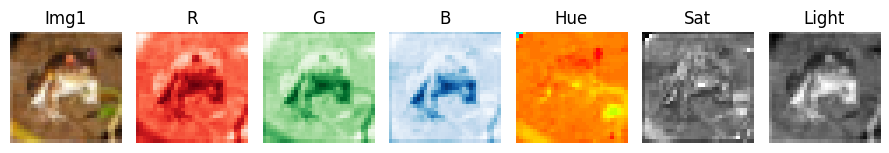

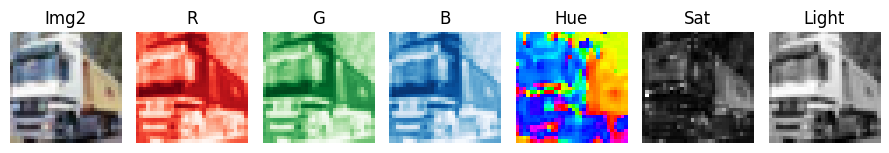

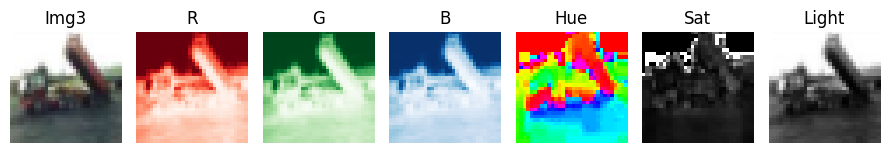

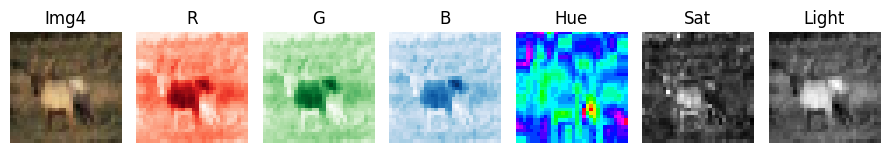

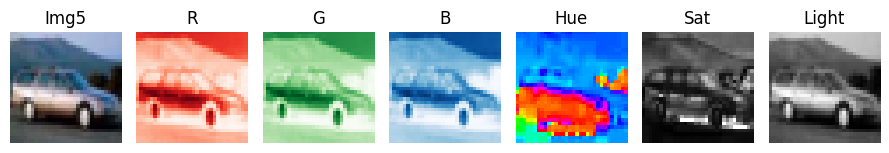

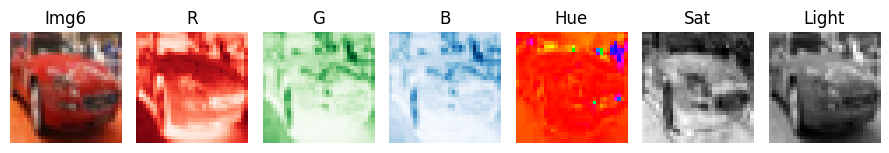

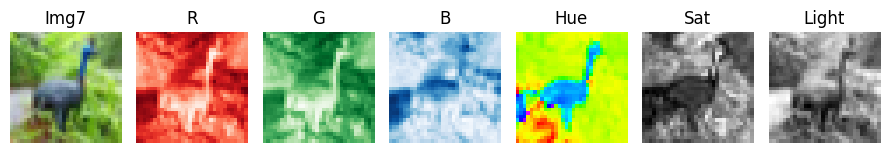

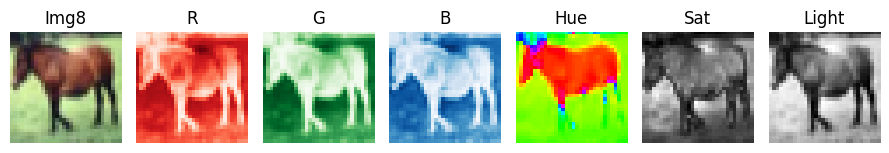

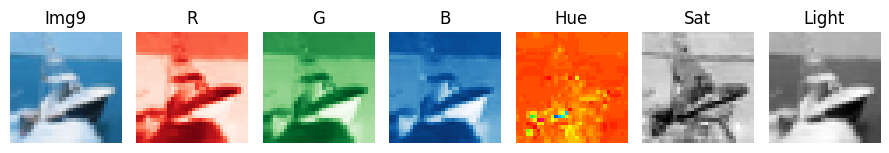

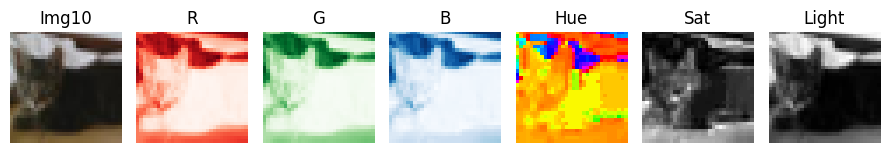

In [12]:
# Pick the first 10 images
for i in range(10):
    img = X_train[i].astype(np.uint8)

    # Convert RGB to HLS (OpenCV uses HLS, which is equivalent to HSL)
    img_hsl = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)

    # Extract channels
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    H, L, S = img_hsl[:,:,0], img_hsl[:,:,1], img_hsl[:,:,2]

    # --- Plot in one row (1×7) ---
    plt.figure(figsize=(9, 5))

    # 1. Original
    plt.subplot(1, 7, 1)
    plt.imshow(img)
    plt.title(f"Img{i+1}")
    plt.axis("off")

    # 2–4. RGB channels
    for j, (ch, name, cmap) in enumerate(zip([R, G, B], ['R', 'G', 'B'], ['Reds', 'Greens', 'Blues']), start=2):
        plt.subplot(1, 7, j)
        plt.imshow(ch, cmap=cmap)
        plt.title(name)
        plt.axis("off")

    # 5–7. HSL channels
    for j, (ch, name, cmap) in enumerate(zip([H, S, L], ['Hue', 'Sat', 'Light'], ['hsv', 'gray', 'gray']), start=5):
        plt.subplot(1, 7, j)
        plt.imshow(ch, cmap=cmap)
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


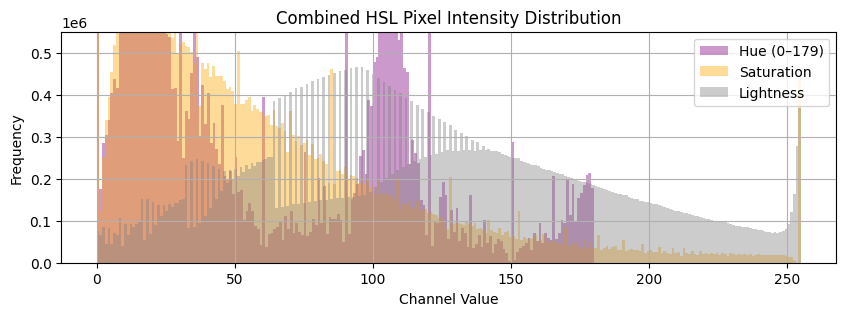

In [13]:
X_train_hsl = np.array([cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2HLS) for img in X_train])

# Separate H, S, L channels
H = X_train_hsl[:, :, :, 0].flatten()   # Hue (0–179 in OpenCV)
S = X_train_hsl[:, :, :, 2].flatten()   # Saturation (0–255)
L = X_train_hsl[:, :, :, 1].flatten()   # Lightness (0–255)

# --- Plot combined histogram ---
plt.figure(figsize=(10, 3))
plt.hist(H, bins=180, color='purple', alpha=0.4, label='Hue (0–179)')
plt.hist(S, bins=256, color='orange', alpha=0.4, label='Saturation')
plt.hist(L, bins=256, color='gray', alpha=0.4, label='Lightness')

plt.title("Combined HSL Pixel Intensity Distribution")
plt.xlabel("Channel Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.ylim(0, 0.55e6)
plt.ticklabel_format(axis='y', style='sci', scilimits=(6,6))
plt.show()


#### Observation among 10 Classes

--- Sample Images for each class ---


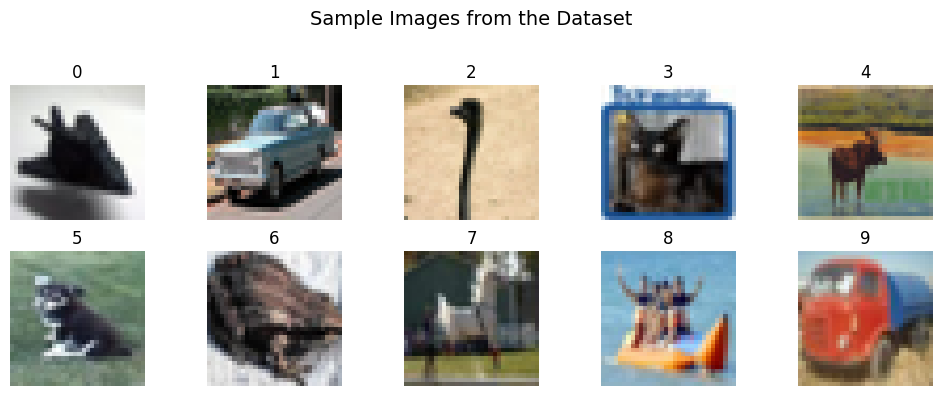

In [14]:
print("--- Sample Images for each class ---")
plt.figure(figsize=(10, 4))
row_index = 0 ; img_index = 0
# loop until we have one image per class (10 total)
while img_index < 10:
    label = y_train[row_index]
    if label == img_index:
        plt.subplot(2, 5, img_index + 1)
        plt.imshow(X_train[row_index])
        plt.title(class_names[label])
        plt.axis('off')
        img_index += 1
    row_index += 1
plt.suptitle("Sample Images from the Dataset", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [15]:
# give the class name manually
class_Names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

--- Average Image per Class ---


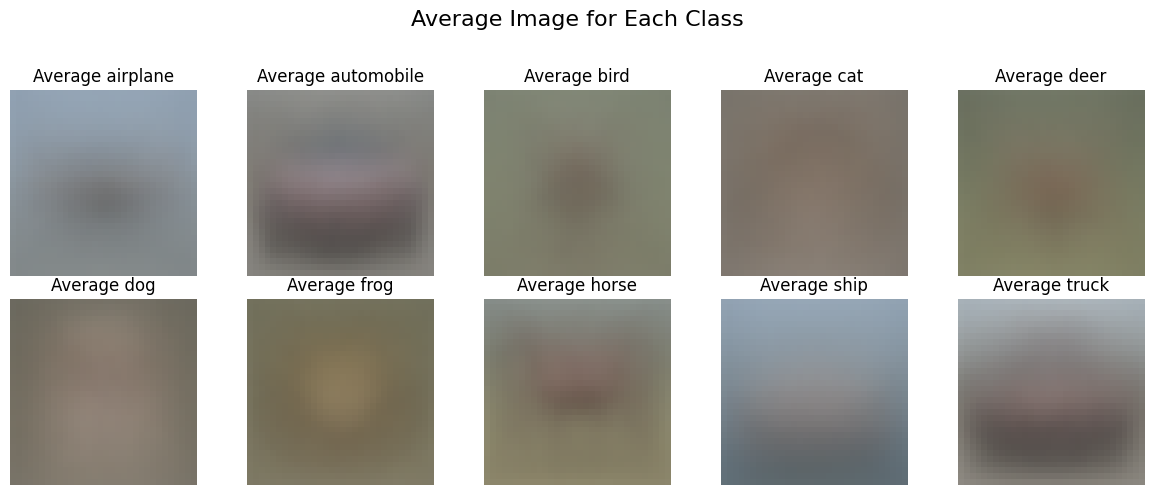

In [16]:
print("--- Average Image per Class ---")

plt.figure(figsize=(12, 5))
for i, class_name in enumerate(class_Names):
    # Find all indices for the current class
    class_indices = np.where(y_train == i)[0]

    # Calculate the mean image for this class
    mean_image = np.mean(X_train[class_indices], axis=0).astype(np.uint8)

    # Plot the mean image
    plt.subplot(2, 5, i + 1)
    plt.imshow(mean_image)
    plt.title(f"Average {class_name}")
    plt.axis('off')

plt.suptitle("Average Image for Each Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

 Exploring Intra-Class Variation 


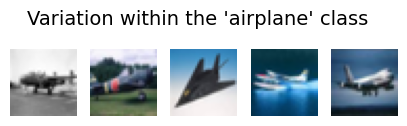

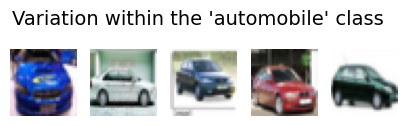

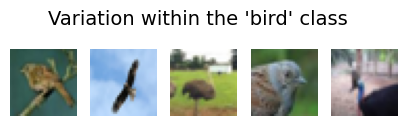

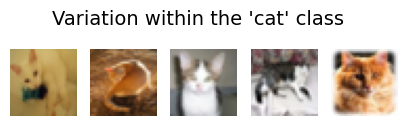

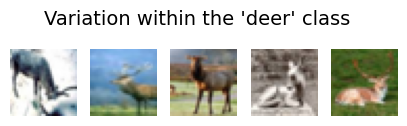

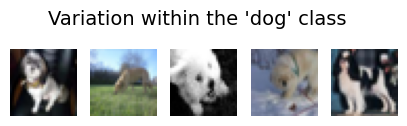

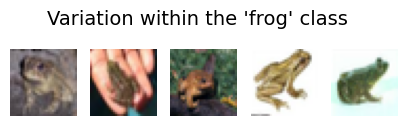

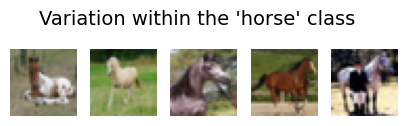

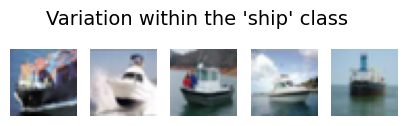

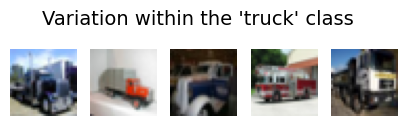

In [17]:
print(" Exploring Intra-Class Variation ")
# Shows how different images within the SAME class can look
def show_class_variation(class_name):
    class_idx = class_Names.index(class_name)
    class_indices = np.where(y_train == class_idx)[0]
    random_indices = np.random.choice(class_indices, 5, replace=False)

    plt.figure(figsize=(5, 1.5))
    for i, idx in enumerate(random_indices):
        plt.subplot(1, 5, i + 1)
        plt.imshow(X_train[idx])
        plt.axis('off')
    plt.suptitle(f"Variation within the '{class_name}' class", fontsize=14)
    plt.show()

for i in class_Names:
    show_class_variation(i)

 Exploring Inter-Class Similarity (Difficulty Factor 2) 


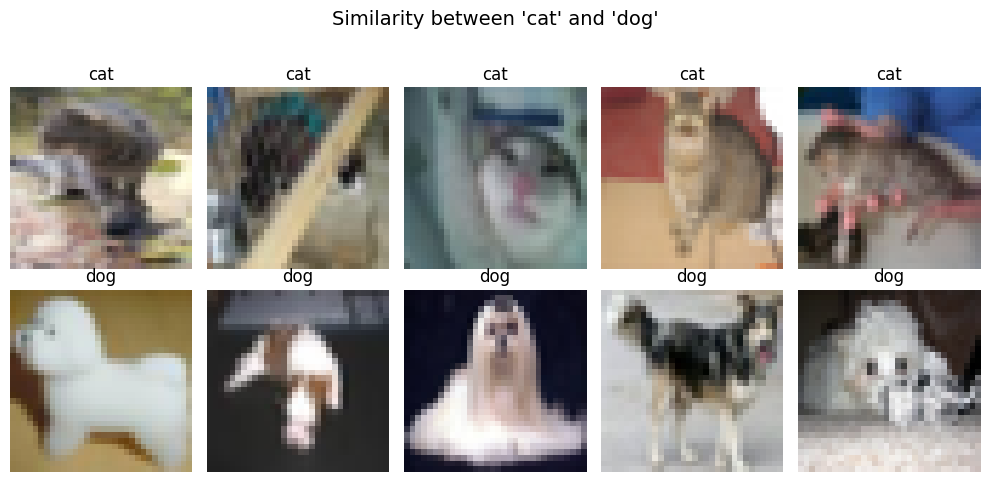

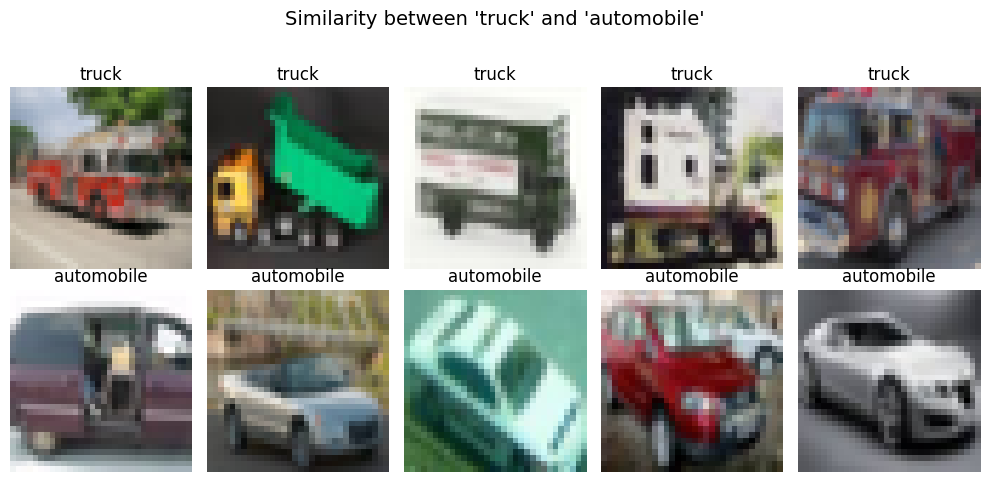

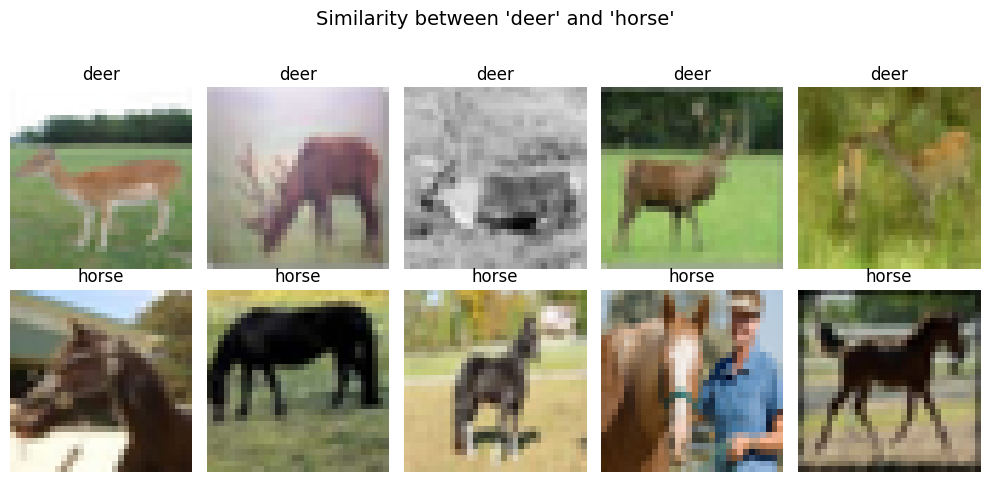

In [18]:
print(" Exploring Inter-Class Similarity (Difficulty Factor 2) ")
# Shows how images from DIFFERENT classes can look very similar
def show_confusable_classes(class1_name, class2_name):
    class1_idx = class_Names.index(class1_name)
    class2_idx = class_Names.index(class2_name)

    class1_indices = np.where(y_train== class1_idx)[0]
    class2_indices = np.where(y_train == class2_idx)[0]

    random1_indices = np.random.choice(class1_indices, 5, replace=False)
    random2_indices = np.random.choice(class2_indices, 5, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    fig.suptitle(f"Similarity between '{class1_name}' and '{class2_name}'", fontsize=14)

    for i in range(5):
        axes[0, i].imshow(X_train[random1_indices[i]])
        axes[0, i].set_title(class1_name)
        axes[0, i].axis('off')
        axes[1, i].imshow(X_train[random2_indices[i]])
        axes[1, i].set_title(class2_name)
        axes[1, i].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

show_confusable_classes('cat', 'dog')
show_confusable_classes('truck', 'automobile')
show_confusable_classes('deer', 'horse')

Analysis of Image Characteristics<br>
The visualizations, particularly the exploration of intra-class variation, reveal several key characteristics of the images that present challenges for classification:

Object Centering: The primary subject of the image (e.g., the 'cat' or 'automobile') is not consistently centered. Objects frequently appear off to one side, at various angles, and at different scales. This lack of consistent alignment means the model must be robust to spatial translation.
Scale Variation: As seen with the 'bird' and 'ship' classes, the object of interest can occupy a small fraction of the image or dominate the entire frame.
Occlusion and Background Clutter: Many images feature complex backgrounds or partial occlusion of the main subject, making it difficult to distinguish the object from its surroundings.
These factors, combined with the low 32x32 resolution, highlight the difficulty of the classification task.

### 1-3 Data Preprocessing

Check the value

In [19]:
# Data quality checks
print("=== Data Quality Checks ===")

# Check pixel values outside 0-255 range
pixel_out_of_range = np.sum((X_train < 0) | (X_train > 255))
print(f"Number of pixel values not in 0~255: {pixel_out_of_range}")

# Check y_train values outside 0-9 range
y_out_of_range = np.sum((y_train < 0) | (y_train > 9))
print(f"Number of y_train values not in 0~9: {y_out_of_range}")

# Check for duplicate rows in X_train
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
unique_rows, counts = np.unique(X_train_reshaped, axis=0, return_counts=True)
duplicate_rows = np.sum(counts > 1)
print(f"Number of rows with duplicates: {duplicate_rows}")



=== Data Quality Checks ===
Number of pixel values not in 0~255: 0
Number of y_train values not in 0~9: 0
Number of rows with duplicates: 0


In [20]:
#Value Normalization
X_train_processed = X_train.astype('float32') / 255.0
X_test_processed = X_test.astype('float32') / 255.0
print("Pixel Normalization for X_train Complete ---")
print(f"Min/Max pixel values after normalization: {X_train_processed.min()}, {X_train_processed.max()}")
print("Pixel Normalization for X_test Complete ---")
print(f"Min/Max pixel values after normalization: {X_test_processed.min()}, {X_test_processed.max()}")

Pixel Normalization for X_train Complete ---
Min/Max pixel values after normalization: 0.0, 1.0
Pixel Normalization for X_test Complete ---
Min/Max pixel values after normalization: 0.0, 1.0


In [21]:
# first six week models require 1D integer labels, which we already have in our original
y_train_sklearn = y_train
y_test_sklearn = y_test

print("y_train_sklearn",y_train_sklearn)
print("y_test_sklearn",y_test_sklearn)

y_train_sklearn [6 9 9 ... 9 1 1]
y_test_sklearn [3 8 8 ... 5 1 7]


In [22]:
# Prepare Labels for Different Model Types
# Neural Networks (MLP & CNN) require one-hot encoded labels.
y_train_nn = tf.keras.utils.to_categorical(y_train, 10)
y_test_nn = tf.keras.utils.to_categorical(y_test, 10)

print("y_train_nn",y_train_nn)
print("y_test_nn",y_test_nn)

y_train_nn [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
y_test_nn [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


In [23]:
# Sample Labels
print("\n--- Label Preparation Complete ---")
print(f"Original label shape: {y_train.shape}")
print(f"Neural Net label shape (one-hot): {y_train_nn.shape}")
print(f"Scikit-learn label shape (1D vector): {y_train_sklearn.shape}")

print(f"Example original label: {y_train[0]}")
print(f"Example one-hot label: {y_train_nn[0]}")
print(f"Example sklearn label: {y_train_sklearn[0]}")



--- Label Preparation Complete ---
Original label shape: (50000,)
Neural Net label shape (one-hot): (50000, 10)
Scikit-learn label shape (1D vector): (50000,)
Example original label: 6
Example one-hot label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Example sklearn label: 6


In [24]:
#Another Color of HSL
X_train_hsl = np.array([cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2HLS) for img in X_train])
X_test_hsl = np.array([cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2HLS) for img in X_test])

#Value Normalization
X_train_proce_hsl = X_train_hsl.astype('float32')
X_train_proce_hsl[:,:,:,0] /= 179.0   # Hue
X_train_proce_hsl[:,:,:,1:] /= 255.0  # Lightness, Saturation
X_test_proce_hsl = X_test_hsl.astype('float32')
X_test_proce_hsl[:,:,:,0] /= 179.0   # Hue
X_test_proce_hsl[:,:,:,1:] /= 255.0  # Lightness, Saturation

In [25]:
#Pooling
X_train_rgb16 = block_reduce(X_train_processed, block_size=(1, 2, 2, 1), func=np.mean)
X_test__rgb16 = block_reduce(X_test_processed , block_size=(1, 2, 2, 1), func=np.mean)
X_train_hsl16 = block_reduce(X_train_proce_hsl, block_size=(1, 2, 2, 1), func=np.mean)
X_test__hsl16 = block_reduce(X_test_proce_hsl , block_size=(1, 2, 2, 1), func=np.mean)

--- Visualizing the Effect of 2x2 Mean Pooling (32x32 vs 16x16) ---


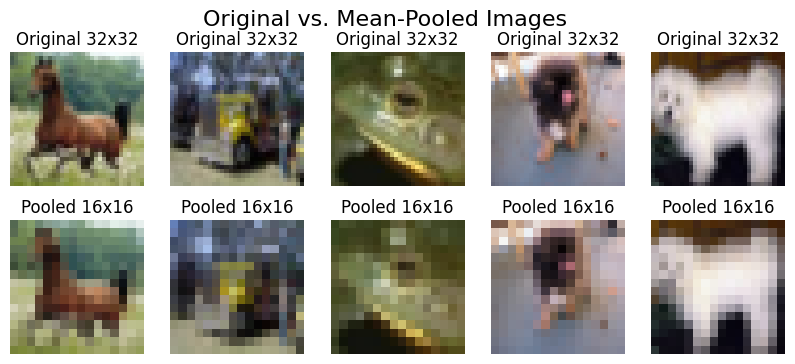

In [26]:
print("--- Visualizing the Effect of 2x2 Mean Pooling (32x32 vs 16x16) ---")

# Select a few random images to show
sample_indices = np.random.choice(len(X_train), 5, replace=False)

plt.figure(figsize=(10, 4))
for i, idx in enumerate(sample_indices):
    # Original 32x32 image
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(f"Original 32x32")
    plt.axis('off')

    # Pooled 16x16 image
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_train_rgb16[idx]) # Using your pooled data
    plt.title(f"Pooled 16x16")
    plt.axis('off')

plt.suptitle("Original vs. Mean-Pooled Images", fontsize=16)
plt.show()

In [27]:
## Creating Splits for train test for each type of model

X_train_flat = X_train_processed.reshape(X_train_processed.shape[0], -1)
X_test_flat = X_test_processed.reshape(X_test_processed.shape[0], -1)
X_train_hsl32F = X_train_proce_hsl.reshape(X_train_proce_hsl.shape[0], -1)
X_test__hsl_32 = X_test_proce_hsl.reshape (X_test_proce_hsl.shape[0], -1)

X_train_rgb16F = X_train_rgb16.reshape(X_train_rgb16.shape[0], -1)
X_test__rgb_16 = X_test__rgb16.reshape(X_test__rgb16.shape[0], -1)
X_train_hsl16F = X_train_hsl16.reshape(X_train_hsl16.shape[0], -1)
X_test__hsl_16 = X_test__hsl16.reshape(X_test__hsl16.shape[0], -1)


# first 6 week tut
X_train_sklearn_split, X_val_sklearn, y_train_sklearn_split, y_val_sklearn_split = train_test_split(
    X_train_flat, y_train_sklearn, test_size=0.2, random_state=42, stratify=y_train_sklearn
)

# MLP

X_train_mlp, X_val_mlp, y_train_mlp, y_val_mlp = train_test_split(
    X_train_flat, y_train_nn, test_size=0.2, random_state=42, stratify=y_train_nn
)

# CNN
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train_processed, y_train_nn, test_size=0.2, random_state=42, stratify=y_train_nn
)

# Data in other formats
X_train_hsl_32, X_valid_hsl_32 = train_test_split( X_train_hsl32F, test_size=0.2, random_state=42, stratify=y_train_nn)
X_train_rgb_16, X_valid_rgb_16 = train_test_split( X_train_rgb16F, test_size=0.2, random_state=42, stratify=y_train_nn)
X_train_hsl_16, X_valid_hsl_16 = train_test_split( X_train_hsl16F, test_size=0.2, random_state=42, stratify=y_train_nn)



In [28]:
### Examples of preprocessed data
# Please print/display some examples of your preprocessed data here.

print("SUMMARY OF FINAL DATA ASSETS")

print("Scikit-learn Model:")
print(f"X_train_sklearn shape: {X_train_sklearn_split.shape}, y_train_sklearn shape: {y_train_sklearn_split.shape}")
print(f"X_val_sklearn shape:   {X_val_sklearn.shape}, y_val_sklearn shape:   {y_val_sklearn_split.shape}")
print(f"X_test_sklearn (use X_test_flat):  {X_test_flat.shape}, y_test_sklearn (use y_test_sklearn):  {y_test_sklearn.shape}")

print("MLP Model:")
print(f"X_train_mlp shape: {X_train_mlp.shape}, y_train_mlp shape: {y_train_mlp.shape}")
print(f"X_val_mlp shape:   {X_val_mlp.shape}, y_val_mlp shape:   {y_val_mlp.shape}")
print(f"X_test_mlp (use X_test_flat):  {X_test_flat.shape}, y_test_mlp (use y_test_nn):  {y_test_nn.shape}")

print("CNN Model:")
print(f"X_train_cnn shape: {X_train_cnn.shape}, y_train_cnn shape: {y_train_cnn.shape}")
print(f"X_val_cnn shape:   {X_val_cnn.shape}, y_val_cnn shape:   {y_val_cnn.shape}")
print(f"X_test_cnn (use X_test_processed):  {X_test_processed.shape}, y_test_cnn (use y_test_nn):  {y_test_nn.shape}")

print("Additional Formats:")
print(f"X_train_hsl_32 shape: {X_train_hsl_32.shape}, X_valid_hsl_32 shape: {X_valid_hsl_32.shape}")
print(f"X_train_rgb_16 shape: {X_train_rgb_16.shape}, X_valid_rgb_16 shape: {X_valid_rgb_16.shape}")
print(f"X_train_hsl_16 shape: {X_train_hsl_16.shape}, X_valid_hsl_16 shape: {X_valid_hsl_16.shape}")


SUMMARY OF FINAL DATA ASSETS
Scikit-learn Model:
X_train_sklearn shape: (40000, 3072), y_train_sklearn shape: (40000,)
X_val_sklearn shape:   (10000, 3072), y_val_sklearn shape:   (10000,)
X_test_sklearn (use X_test_flat):  (10000, 3072), y_test_sklearn (use y_test_sklearn):  (10000,)
MLP Model:
X_train_mlp shape: (40000, 3072), y_train_mlp shape: (40000, 10)
X_val_mlp shape:   (10000, 3072), y_val_mlp shape:   (10000, 10)
X_test_mlp (use X_test_flat):  (10000, 3072), y_test_mlp (use y_test_nn):  (10000, 10)
CNN Model:
X_train_cnn shape: (40000, 32, 32, 3), y_train_cnn shape: (40000, 10)
X_val_cnn shape:   (10000, 32, 32, 3), y_val_cnn shape:   (10000, 10)
X_test_cnn (use X_test_processed):  (10000, 32, 32, 3), y_test_cnn (use y_test_nn):  (10000, 10)
Additional Formats:
X_train_hsl_32 shape: (40000, 3072), X_valid_hsl_32 shape: (10000, 3072)
X_train_rgb_16 shape: (40000, 768), X_valid_rgb_16 shape: (10000, 768)
X_train_hsl_16 shape: (40000, 768), X_valid_hsl_16 shape: (10000, 768)


## 2. Algorithm design and setup



### 2-1 Algorithm of choice from first six weeks of course

In [68]:
### Baseline PCA + Linear SVM (no tuning)

baseline = Pipeline([
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("svm", LinearSVC(C=1.0, dual="auto", max_iter=5000, random_state=42))
])

print("Fitting baseline (PCA 95% + LinearSVC C=1.0)...")
baseline.fit(X_train_sklearn_split, y_train_sklearn_split)

# validation
svm_y_val_pred_base = baseline.predict(X_val_sklearn)
val_acc_base = accuracy_score(y_val_sklearn_split, svm_y_val_pred_base)
print(f"Baseline validation accuracy: {val_acc_base:.4f}")

# test
svm_y_test_pred_base = baseline.predict(X_test_flat)
svm_test_acc_base = accuracy_score(y_test_sklearn, svm_y_test_pred_base)
print(f"Baseline test accuracy: {svm_test_acc_base:.4f}")


Fitting baseline (PCA 95% + LinearSVC C=1.0)...
Baseline validation accuracy: 0.4066
Baseline test accuracy: 0.4001


### 2-2 Fully connected neural network MLP

In [29]:
###  implement an instance of MLP

mlp_base_model = keras.models.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(3072,)),
    keras.layers.Dense(10, activation='softmax')
])

mlp_base_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = mlp_base_model.fit(
    X_train_mlp, y_train_mlp,
    epochs=1,
    batch_size=256,
    validation_data=(X_val_mlp, y_val_mlp),
    verbose=0,
    shuffle=False
)

/Users/chingyu/anaconda3/envs/tf-m4/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-26 00:22:31.044120: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-10-26 00:22:31.044668: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-26 00:22:31.044683: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-10-26 00:22:31.045085: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-26 00:22:31.045104: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271

In [30]:
### parameters for tuning
activations = [
    'relu',
    'leaky_relu',
    #'tanh',
    #'sigmoid',
    ]
layer_nodes = {
    "128": [128],
    "64": [64],
    "32": [32],
    "128-32": [128, 32],
    "32-128": [32, 128],
    "64-32": [64, 32],
    "32-64": [32,64]
}
optimisers = [
    #("SGD", 0.001),
    #("SGD", 0.01),
    ("Adam", 0.001),
    #("Adam", 0.01)
]
batch_sizes = [64, 128]

In [31]:
### input diff parameter to tune
def mlp_tuning_model(X_train, y_train, X_val, y_val,
                     activations=['leaky_relu'],
                     layer_nodes={"128-32-10": [128, 32]},
                     optimisers=[("Adam", 0.001)],
                     epochs=10,
                     batch_sizes=[128]):

    results = {}
    print(f"training on {len(X_train)} data...")

    # loop through all combinations
    for acti in activations:
        for name_opt, lr in optimisers:  # Get optimizer name and learning rate
            for layer_name, nodes in layer_nodes.items():
                for bsize in batch_sizes:

                    # --- build model ---
                    model = keras.Sequential()
                    model.add(keras.layers.Input(shape=(X_train.shape[1],)))
                    for n in nodes:
                        model.add(keras.layers.Dense(n, activation=acti))
                    model.add(keras.layers.Dense(10, activation='softmax'))

                    # optimizer setting
                    if name_opt == "SGD":
                        opt = keras.optimizers.SGD(learning_rate=lr)
                    elif name_opt == "Adam":
                        opt = keras.optimizers.Adam(learning_rate=lr)
                    elif name_opt == "RMSprop":
                        opt = keras.optimizers.RMSprop(learning_rate=lr)

                    model.compile(optimizer=opt,
                                  loss='categorical_crossentropy',
                                  metrics=['accuracy'])

                    # --- train model ---
                    start_time = time.time()
                    history = model.fit(
                        X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=bsize,
                        verbose=0,
                        shuffle=False
                    )
                    duration = time.time() - start_time

                    # --- get result ---
                    Fir_HLayer_nodes = nodes[0]
                    Sec_HLayer_nodes = nodes[1] if len(nodes) > 1 else None
                    val_acc = round(max(history.history['val_accuracy']),4)
                    
                    print(f'complete for: {acti}-{layer_name}-bs{bsize}. val_acc: {val_acc:.4f}, duration: {duration:.2f}s')
                    results[f"{acti}-{layer_name}-bs{bsize}"] = [acti, Fir_HLayer_nodes, Sec_HLayer_nodes, bsize, name_opt, lr, val_acc, duration]

    df = pd.DataFrame(results, index=["activation","FirstHLayerNodes","SecHLayerNodes","BatchSize","Optimisers","LearningRate","Val Acc", "Durations"])

    return df, history

In [32]:
### simplfiy version: after best parameters are found
def train_ensemble_model(df_name, X_train, y_train, X_val, y_val, input_dim, act, node1, node2, bats, epoch):
    layers = [
        keras.layers.Dense(node1, activation=act, input_shape=(input_dim,))
    ]
    if node2 > 0:
        layers.append(keras.layers.Dense(node2, activation=act))
    layers.append(keras.layers.Dense(10, activation='softmax'))
    model = keras.models.Sequential(layers)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        epochs=epoch,
        batch_size=bats,
        validation_data=(X_val, y_val),
        verbose=0,
        shuffle=False
    )
    return model, history

In [33]:
### combine four models by weighted
def ensemble_predict_weighted(models_info):
    model_names = list(models_info.keys())
    preds = []

    for name in model_names:
        model = models_info[name]["model"]
        X = models_info[name]["X_test"]
        preds.append(model.predict(X, verbose=0))

    preds = np.stack(preds, axis=-1)  # (samples, classes, models)
    num_classes = preds.shape[1]
    weighted_preds = np.zeros(preds.shape[:2])

    for c in range(num_classes):
        for m_idx, name in enumerate(model_names):
            w = models_info[name]["class_weights"].iloc[c]
            weighted_preds[:, c] += preds[:, c, m_idx] * w

    return np.argmax(weighted_preds, axis=1)

### 2-3 Convolutional neural network CNN

In [ ]:
'CNN Model'
#Three conv blocks with max pooling, then a 1024-unit dense layer and softmax output
#Ajala, S. (2021). Convolutional Neural Network Implementation for Image Classification using CIFAR-10 Dataset. ResearchGate.

#build CNN model
cnn_base_model = Sequential([
    #Input: 32x32x3 RGB
    #First convolutional and pooling layer
    Conv2D(32, (3, 3), activation='relu', padding='valid', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    #Second convolutional and pooling layer
    Conv2D(64, (3, 3), activation='relu', padding='valid'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    #Third convolutional and pooling layer
    Conv2D(64, (3, 3), activation='relu', padding='valid'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    #fully connected layer
    Flatten(),
    Dense(1024, activation='relu'),
    Dense(10, activation='softmax')  #10 output classes for CIFAR-10
])

#compile model
cnn_base_model.compile(
    optimizer=Adam(learning_rate=0.001),           #Adam optimizer with default betas
    loss='categorical_crossentropy',         #for integer labels 0-9
    metrics=['accuracy']                            #track accuracy metric
)

#display model summary
cnn_base_model.summary()

#train model using training and validation sets (not test set)
history = cnn_base_model.fit(
    X_train_cnn, y_train_cnn,                      #training set
    batch_size=128,                                #mini-batch size
    epochs=20,                                     #number of epochs
    validation_data=(X_val_cnn, y_val_cnn),        #validation set
    verbose=1                                      #show training progress
)


/home/alfonso/ENTER/envs/tfgpu/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,738 (1.26 MB)

 Trainable params: 329,738 (1.26 MB)

...

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3046 - loss: 1.8631

2025-10-23 21:01:27.439855: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_393', 4 bytes spill stores, 4 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3049 - loss: 1.8623

2025-10-23 21:01:34.134151: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151', 4 bytes spill stores, 4 bytes spill loads

2025-10-23 21:01:34.149876: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151', 8 bytes spill stores, 8 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.3945 - loss: 1.6429 - val_accuracy: 0.4931 - val_loss: 1.3856
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5383 - loss: 1.2853 - val_accuracy: 0.5622 - val_loss: 1.2310
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5989 - loss: 1.1325 - val_accuracy: 0.5976 - val_loss: 1.1393
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6356 - loss: 1.0314 - val_accuracy: 0.6313 - val_loss: 1.0436
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6646 - loss: 0.9550 - val_accuracy: 0.6551 - val_loss: 0.9954
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6865 - loss: 0.8946 - val_accuracy: 0.6562 - val_loss: 0.9872
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7090 - loss: 0.8320 - val_accuracy: 0.6669 - val_loss: 0.9665
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7291 - loss: 0.7738 - val_accuracy: 0.6764 - v

In [ ]:
### model builder function for random search
def build_model(hp: kt.HyperParameters) -> keras.Model:
    inputs = keras.Input(shape=(32, 32, 3))

    #Conv block 1
    x = keras.layers.Conv2D(
        filters=hp.Choice('filters1', [32, 64, 96]),                  #this controls model capacity
        kernel_size=3,
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(hp.Float('l2_reg', 1e-5, 1e-3, sampling='log'))  #L2 regularisation
    )(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)

    #Conv block 2
    x = keras.layers.Conv2D(
        filters=hp.Choice('filters2', [64, 96, 128]),                 #progressively higher filter counts
        kernel_size=3,
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(hp.Float('l2_reg', 1e-5, 1e-3, sampling='log'))
    )(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)

    #Conv block 3
    x = keras.layers.Conv2D(
        filters=hp.Choice('filters3', [96, 128, 160]),                #upper range capped to control variance and runtime
        kernel_size=3,
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(hp.Float('l2_reg', 1e-5, 1e-3, sampling='log'))
    )(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2)(x)

    #Flatten + dropout regularisation
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(rate=hp.Choice('dropout_rate', [0.3, 0.4, 0.5]))(x)   #dropout rate to reduce overfitting

    #dense head
    x = keras.layers.Dense(
        1024, activation='relu',
        kernel_regularizer=regularizers.l2(hp.Float('l2_reg', 1e-5, 1e-3, sampling='log'))
    )(x)
    outputs = keras.layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    #compile model with tunable learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4, 1e-4]) ##covers stable to faster convergence
        ),
        loss='categorical_crossentropy',  #use categorical since labels are one-hot encoding
        metrics=['accuracy']
    )
    return model


#custom tuner to allow batch_size tuning
class MyTuner(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        #tune batch size as a fit-time argument
        hp = trial.hyperparameters
        kwargs['batch_size'] = hp.Choice('batch_size', [32, 64, 96, 128])  #smaller batches can help generalisation

        #start timer
        start = time.time()

        #run the actual training for this trial
        result = super().run_trial(trial, *args, **kwargs)

        #elapsed time in seconds
        elapsed = time.time() - start

        #store training time as a custom metric so it’s saved with the trial
        if "train_time" not in trial.metrics.metrics:
            trial.metrics.register("train_time", "min")  #we just record a single value
        trial.metrics.update("train_time", elapsed)

        print(f"Trial {trial.trial_id} training time: {elapsed/60:.2f} min")

        return result

### 2-4 Supporting Def function : Graph / Save File

In [34]:
def round_to_nearest(x, step=0.05, direction='up'):
    if direction == 'up':
        return np.ceil(x / step) * step
    else:
        return np.floor(x / step) * step

In [35]:
def plot_tuning_result(SetResult, figsize=(6, 4), legend=True):
    global_acc = []
    global_dur = []
    for model_name, result_df in SetResult.items():
        global_acc.extend(result_df.loc['Val Acc', :].to_numpy())
        global_dur.extend(result_df.loc['Durations', :].to_numpy())

    max_acc = round_to_nearest(np.percentile(global_acc, 95), 0.02, 'up')+0.02
    min_acc = round_to_nearest(np.percentile(global_acc,  5), 0.02, 'down')-0.02
    max_dur = round_to_nearest(np.percentile(global_dur, 95), 2, 'up')+2
    min_dur = round_to_nearest(np.percentile(global_dur,  5), 2, 'down')-2

    for model_name, result_df in SetResult.items():
        fig, ax = plt.subplots(figsize=figsize)

        # Loop over each tuning configuration
        for col_name in result_df.columns:
            activati = result_df.loc['activation', col_name]
            node1lay = result_df.loc['FirstHLayerNodes', col_name]
            node2lay = result_df.loc['SecHLayerNodes', col_name]
            batchSiz = result_df.loc['BatchSize', col_name]
            accuracy = result_df.loc['Val Acc', col_name]
            duration = result_df.loc['Durations', col_name]
            node2lay = 0 if node2lay is None else node2lay

            # Visual attributes
            color = '#5DD1D8' if activati == 'relu' else '#F68E17'
            marker = 'o' if batchSiz == 128 else 's'
            linewidth = 1 if pd.isna(node2lay) else 2
            size = (node1lay+ node2lay) * 2

            if pd.isna(node2lay):
                linecolor = 'black'
            elif node1lay < node2lay:
                linecolor = '#860C02'  # ascending
            else:
                linecolor = '#010881'  # descending

            # Plot each point
            ax.scatter(
                accuracy, duration,
                c=color, s=size, marker=marker,
                edgecolors=linecolor, linewidth=linewidth, alpha=0.7
            )

        # --- Axes formatting ---
        ax.set_xlim(min_acc, max_acc)
        ax.set_ylim(min_dur, max_dur)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
        ax.set_xlabel('Accuracy', fontsize=9)
        ax.set_ylabel('Duration (sec)', fontsize=9)
        ax.set_title(f'Model: {model_name}', fontsize=11)
        ax.grid(True, alpha=0.3)

        # --- Legend ---
        if legend:
            legend_elements = [
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#5DD1D8', markersize=8,
                          label='ReLU', markeredgecolor='#5DD1D8'),
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#F68E17', markersize=8,
                          label='Leaky ReLU', markeredgecolor='#F68E17'),
                plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=8,
                          label='Batch Size 64', markeredgecolor='gray'),
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8,
                          label='Batch Size 128', markeredgecolor='gray'),
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=8,
                          label='Single HLayer', markeredgecolor='black', markeredgewidth=1),
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=8,
                          label='Two HLayers ASC', markeredgecolor='#860C02', markeredgewidth=3),
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=8,
                          label='Two HLayers DESC', markeredgecolor='#010881', markeredgewidth=3),
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=7,
                          label='Few Nodes'),
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=12,
                          label='Many Nodes')
            ]
            ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

        plt.tight_layout()
        plt.show()

    print("All figures generated using real data!")


In [36]:
def plot_training_curves(history, metric='accuracy', name='', setylim=False, figsize=(6, 4), secline = '--'): 

    plt.figure(figsize=figsize)

    # --- Main metric ---
    plt.plot(history.history[metric], label=f"Training {metric}", linestyle='-')
    plt.plot(history.history[f'val_{metric}'], label=f"Validation {metric}", linestyle= secline)

    plt.title(f"{name} Training vs Validation {metric} per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel(metric)

    if setylim:
        if '-' in name:
            plt.ylim(0.3, 0.6)

    plt.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [37]:
# --- Overlay: components (left y) + best CV accuracy (right y) WITH LEGEND ---
def plot_pca_components_vs_accuracy(
    k_table,
    svm_cv_summary,
    var_col="pca_var_target",
    comp_col="k_components",
    acc_col="cv_mean_acc",
    title="Components vs. Best CV Accuracy per Variance Target",
    figsize=(7, 4),
    save_path=None
):
    # --- Get best accuracy by variance ---
    best_by_var = (
        svm_cv_summary.groupby(var_col, as_index=False)
                      .agg({acc_col: "max"})
    )

    # --- Merge with component table ---
    merged = k_table.merge(best_by_var, on=var_col, how="left")

    # --- Create plot ---
    fig, ax1 = plt.subplots(figsize=figsize)

    # Left y-axis: number of components
    line1, = ax1.plot(
        merged[var_col], merged[comp_col],
        marker="o", linestyle="-", color="#1f77b4", label="# components (k)"
    )
    ax1.set_xlabel("PCA variance target")
    ax1.set_ylabel("# components (k)", color="#1f77b4")

    # Right y-axis: best CV accuracy
    ax2 = ax1.twinx()
    line2, = ax2.plot(
        merged[var_col], merged[acc_col],
        marker="s", linestyle="--", color="green", label="Best CV accuracy"
    )
    ax2.set_ylabel("Best CV accuracy", color="green")

    # Combine legends from both axes
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left", frameon=False)

    plt.title(title)
    fig.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=200)

    plt.show()

    return merged


In [ ]:
def plot_percent_heatmap(df, title='', cmap='Blues', figsize=(6,4),
                         agg_by=None, pivot_by= None, fmt=".2f", XYlabel=False, linew=0,cbar=False):

    if pivot_by is not None:
        index_col, columns_col, values_col = pivot_by
        df_plot = (
            df.pivot(index=index_col, columns=columns_col, values=values_col)
                  .sort_index(ascending=True)
        )
    else:
        df_plot = df

    # --- Plot ---
    plt.figure(figsize=figsize)
    sns.heatmap(
        df_plot,
        annot=True,
        fmt=fmt,
        cmap=sns.color_palette(cmap, as_cmap=True),
        cbar=cbar,
        linewidths=linew,
        linecolor='black'
    )

    plt.title(title, fontsize=14, pad=6)
    if XYlabel:
        Xlabel, Ylabel = XYlabel
        plt.xlabel(Xlabel)
        plt.ylabel(Ylabel)
    else:
        plt.xlabel('')
        plt.ylabel('')
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig('/figs/'+title+".png", dpi=200)
    plt.show()

    return df_plot 


In [ ]:
def plot_runtime_heatmap(df, value_col, title, fmt=".2f", cmap="viridis"):
    pivot_df = (
        df.pivot(index="pca_var_target", columns="svm_C", values=value_col)
          .sort_index(ascending=True)
    )
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot_df, annot=True, fmt=fmt, cmap=sns.color_palette(cmap, as_cmap=True))

    plt.title(title)
    plt.ylabel("PCA variance target")
    plt.xlabel("SVM C")
    plt.tight_layout()
    plt.savefig('/figs/'+title+".png", dpi=200)
    plt.show()


In [40]:
def _plot_param(ax, df, param, log_x=False, title=""):
    #get unique x-values in sorted order
    x_vals = sorted(df[param].unique())
    #scatter all individual trials for context
    for x in x_vals:
        y = df.loc[df[param] == x, "val_accuracy"].values
        x_array = np.full_like(y, fill_value=x, dtype=float)
        jitter = (np.random.rand(len(y)) - 0.5) * (0.03 if not log_x else 0.01)  #adds small jitter
        ax.scatter(x_array + jitter, y, alpha=0.6, color='blue', s=40)
    #calculate and plot mean accuracy for each parameter value
    means = df.groupby(param)["val_accuracy"].mean().reindex(x_vals).values
    ax.plot(
        x_vals, means,
        linestyle='--', linewidth=1.2, marker='o', markersize=3,
        color='grey', alpha=0.9, label='Mean accuracy'
    )
    #format axes
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(param)
    ax.set_ylabel("validation accuracy")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_ylim(0.0, 1.0)
    ax.legend(loc="best", fontsize=8)

In [41]:
def save_SetResult(SetResult, filename="assignment_results_final.xlsx"):

    try:
        all_results = []
        with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
            for name, result  in SetResult.items():
                df = result.copy()

                # Add SetName column based on index
                df['SetName'] = df.index.map(lambda idx: name if idx in ('Val Acc', 'Durations') else '')
                matching_rows = df[df['SetName'] != '']

                # Move SetName to first column
                cols = ['SetName'] + [col for col in df.columns if col != 'SetName']
                df = df[cols]

                all_results.append(df)

            final_df = pd.concat(all_results)
            final_df.drop_duplicates(inplace=True)
            final_df.to_excel(writer, sheet_name="Tuning Result", index=True)

        print(f"Excel file saved successfully: {filename}")
        return True

    except Exception as e:
        print(f"Error saving results: {e}")
        return False

## 3. Hyperparameter tuning

### 3-1 Algorithm of choice from first six weeks of course

In [70]:
### SVM Setting 

svm_pipe = Pipeline([
    ("pca", PCA(svd_solver="full")),
    ("svm", LinearSVC(dual="auto", max_iter=5000, random_state=42))
])

# at least 2 hyperparameters (here: PCA variance target and SVM C)
svm_param_grid = {
    "pca__n_components": [0.80, 0.90, 0.95, 0.99],
    "svm__C": [0.05, 0.1, 0.5, 1, 5, 10],
}

CV_FOLDS = 3
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

In [71]:
### GridSearchCV for PCA + Linear SVM

print("Running GridSearchCV...")
t0 = time.time()
svm_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)
svm_search.fit(X_train_sklearn_split, y_train_sklearn_split)
t1 = time.time()
print(f"GridSearchCV total wall time: {t1 - t0:.1f}s")

print("\nBest params:", svm_search.best_params_)
print("Best CV accuracy: {:.4f}".format(svm_search.best_score_))

# Record CV results (runtimes + scores) ----
cvres = pd.DataFrame(svm_search.cv_results_)
svm_cv_summary = (cvres.loc[:, [
                "rank_test_score","mean_test_score","std_test_score",
                "mean_fit_time","std_fit_time","mean_score_time","std_score_time",
                "param_pca__n_components","param_svm__C"
          ]]
          .sort_values("rank_test_score")
          .rename(columns={
              "mean_test_score":"cv_mean_acc",
              "std_test_score":"cv_std_acc",
              "param_pca__n_components":"pca_var_target",
              "param_svm__C":"svm_C",
          }))
print("\n=== Grid summary (top rows) ===")
print(svm_cv_summary.head(10).to_string(index=False))


Running GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
GridSearchCV total wall time: 768.8s

Best params: {'pca__n_components': 0.95, 'svm__C': 5}
Best CV accuracy: 0.4013

=== Grid summary (top rows) ===
 rank_test_score  cv_mean_acc  cv_std_acc  mean_fit_time  std_fit_time  mean_score_time  std_score_time  pca_var_target  svm_C
               1     0.401275    0.003107      74.052178      2.578171         2.314112        1.363317            0.95   5.00
               2     0.401250    0.003076      79.870968      3.424486         1.620520        0.217591            0.95  10.00
               2     0.401250    0.003108      76.467501      4.071557         1.969135        0.938708            0.95   1.00
               2     0.401250    0.003108      81.558202      1.623800         1.241054        0.023435            0.95   0.50
               5     0.401200    0.003113      91.091028      8.367517         2.311501        1.717374            0.95   0.10
   

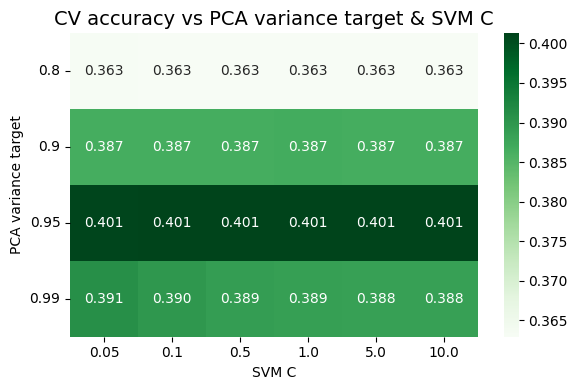


Validation accuracy (best model): 0.4066
Test accuracy (best model): 0.4001
Original dims: 3072  |  Reduced dims: 216


In [72]:
### Result of SVM Grid Search

# Heatmap of CV accuracy
plot_percent_heatmap(
    df=svm_cv_summary,
    title="CV accuracy vs PCA variance target & SVM C",
    cmap="Greens",
    pivot_by=["pca_var_target", "svm_C","cv_mean_acc"],
    fmt=".3f",
    XYlabel=["SVM C","PCA variance target"],
    cbar=True
)

# Validation accuracy with the best model
svm_best_model = svm_search.best_estimator_
svm_y_val_pred = svm_best_model.predict(X_val_sklearn)
svm_val_acc = accuracy_score(y_val_sklearn_split, svm_y_val_pred)
print("\nValidation accuracy (best model): {:.4f}".format(svm_val_acc))

# Test accuracy with the best model (so you can compare to baseline)
svm_y_test_pred = svm_best_model.predict(X_test_flat)
svm_test_acc = accuracy_score(y_test_sklearn, svm_y_test_pred)
print("Test accuracy (best model): {:.4f}".format(svm_test_acc))

# Report the resolved number of PCA components for the best model
pca_step = svm_best_model.named_steps["pca"]
print(f"Original dims: {X_train_sklearn_split.shape[1]}  |  Reduced dims: {pca_step.n_components_}")

In [73]:
### SVM Chosen hyperparameters (edit these after you run the grid once) =====
CHOSEN_PCA_VAR = svm_search.best_params_['pca__n_components']
CHOSEN_SVM_C   = svm_search.best_params_['svm__C']

print("Using chosen hyperparameters:")
print("  PCA variance target:", CHOSEN_PCA_VAR)
print("  SVM C:", CHOSEN_SVM_C)


Using chosen hyperparameters:
  PCA variance target: 0.95
  SVM C: 5


### 3-2 Fully connected neural network

In [42]:
MLP_tuning_Set = {"RGB-OriS":[X_train_mlp   , y_train_mlp, X_val_mlp     , y_val_mlp],
              "RGB-Pool":[X_train_rgb_16, y_train_mlp, X_valid_rgb_16, y_val_mlp],
              "HSL-OriS":[X_train_hsl_32, y_train_mlp, X_valid_hsl_32, y_val_mlp],
              "HSL-Pool":[X_train_hsl_16, y_train_mlp, X_valid_hsl_16, y_val_mlp],
             }
MLP_TuneResult = {}

#### 3-2-1 Phase 1 tuning

In [47]:
for name, (Xtr, ytr, Xv, yv) in MLP_tuning_Set.items():
    print(f"Training model for {name}...")

    input_dim = Xtr.shape[1]

    result, history = mlp_tuning_model(Xtr, ytr, Xv, yv,
                                            activations = activations,
                                            layer_nodes=layer_nodes,
                                            batch_sizes=batch_sizes,
                                            epochs=3)
    MLP_TuneResult[name]= result

save_SetResult(MLP_TuneResult, filename="tuning_result.xlsx")

Training model for RGB-OriS...
training on 40000 data...
complete for: relu-128-bs64. val_acc: 0.3246, duration: 20.17s
complete for: relu-128-bs128. val_acc: 0.3409, duration: 9.09s
complete for: relu-64-bs64. val_acc: 0.3555, duration: 16.58s
complete for: relu-64-bs128. val_acc: 0.3198, duration: 9.23s
complete for: relu-32-bs64. val_acc: 0.3213, duration: 15.80s
complete for: relu-32-bs128. val_acc: 0.2466, duration: 9.02s
complete for: relu-128-32-bs64. val_acc: 0.2790, duration: 18.48s
complete for: relu-128-32-bs128. val_acc: 0.2059, duration: 10.19s
complete for: relu-32-128-bs64. val_acc: 0.3015, duration: 18.46s
complete for: relu-32-128-bs128. val_acc: 0.2752, duration: 10.05s
complete for: relu-64-32-bs64. val_acc: 0.2942, duration: 18.19s
complete for: relu-64-32-bs128. val_acc: 0.3028, duration: 10.05s
complete for: relu-32-64-bs64. val_acc: 0.2897, duration: 18.05s
complete for: relu-32-64-bs128. val_acc: 0.3234, duration: 10.03s
complete for: leaky_relu-128-bs64. val_ac

True

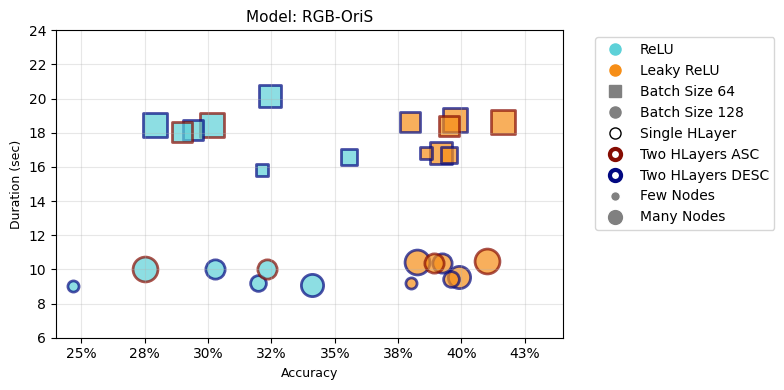

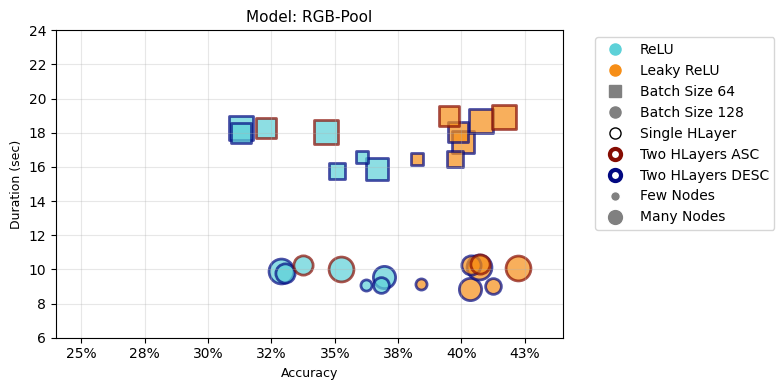

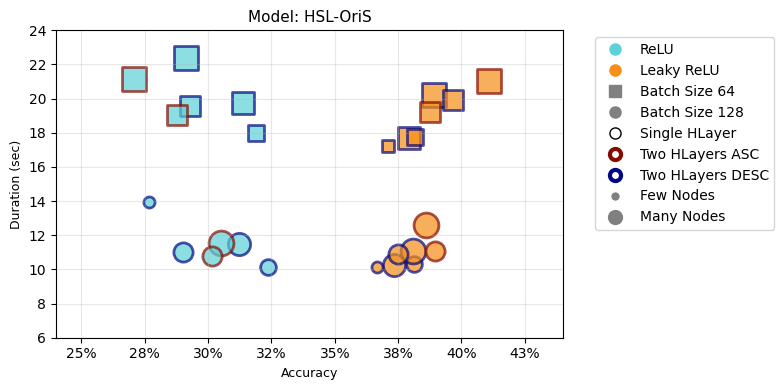

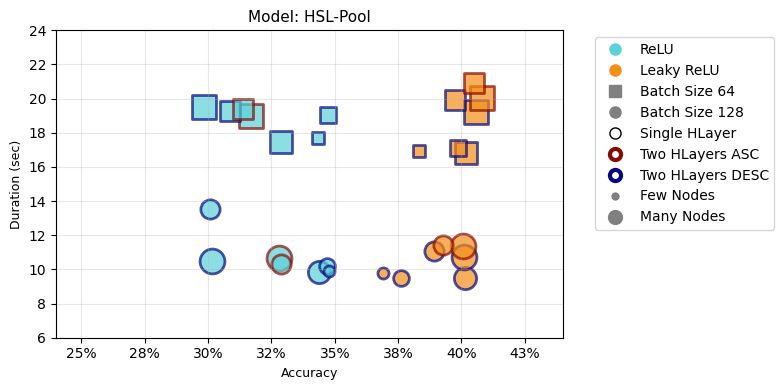

All figures generated using real data!


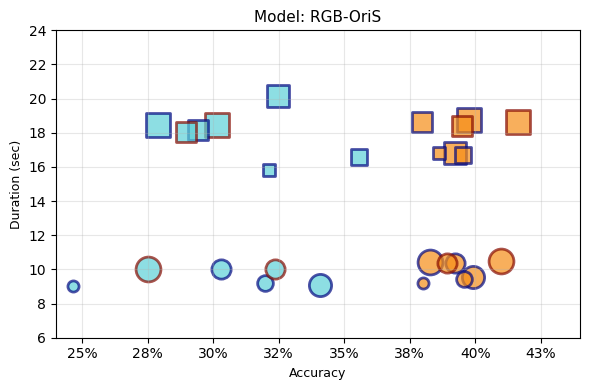

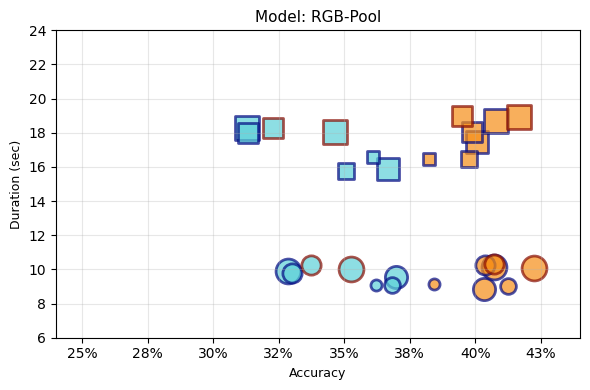

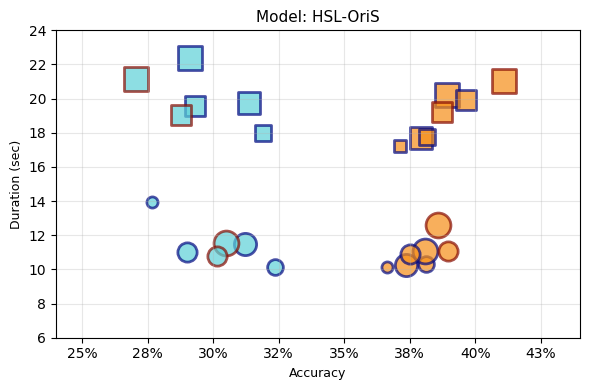

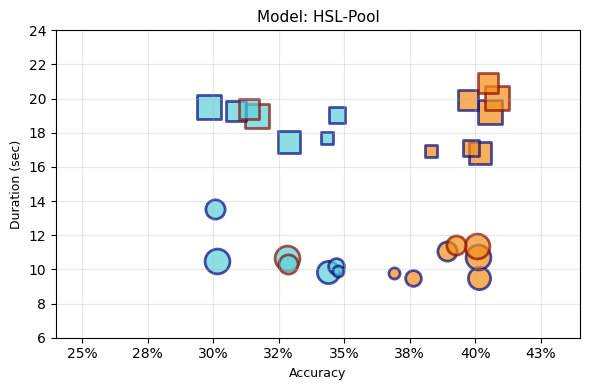

All figures generated using real data!


In [48]:
plot_tuning_result(MLP_TuneResult, figsize = (8,4), legend=True)
plot_tuning_result(MLP_TuneResult, legend=False)

#### 3-2-2 Phase 2 tuning (Epoch)

In [51]:
mlp_parameter = {
    "RGB-OriS": (X_train_mlp,    y_train_mlp, X_val_mlp,      y_val_mlp, 'leaky_relu',32, 128, 128, 50, X_test_flat), # X test for later use, just save in dict first
    "RGB-Pool": (X_train_rgb_16, y_train_mlp, X_valid_rgb_16, y_val_mlp, 'leaky_relu',32, 128, 128, 50, X_test__rgb_16),
    "HSL-OriS": (X_train_hsl_32, y_train_mlp, X_valid_hsl_32, y_val_mlp, 'leaky_relu',32, 128, 128, 50, X_test__hsl_32),
    "HSL-Pool": (X_train_hsl_16, y_train_mlp, X_valid_hsl_16, y_val_mlp, 'leaky_relu',32, 128, 64, 50, X_test__hsl_16)
}

Training model for RGB-OriS...
RGB-OriS accuracy: 0.4853
RGB-OriS duration: 193.3065 seconds


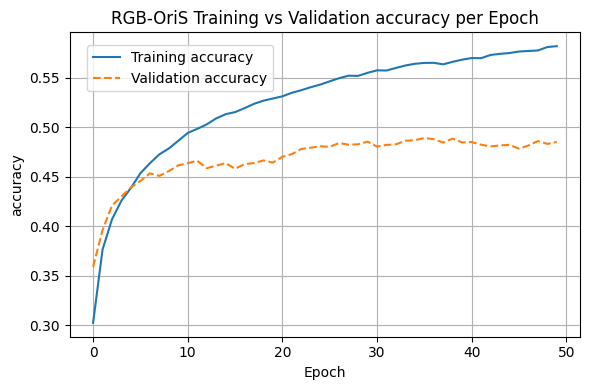

Training model for RGB-Pool...


/Users/chingyu/anaconda3/envs/tf-m4/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RGB-Pool accuracy: 0.4961
RGB-Pool duration: 174.4312 seconds


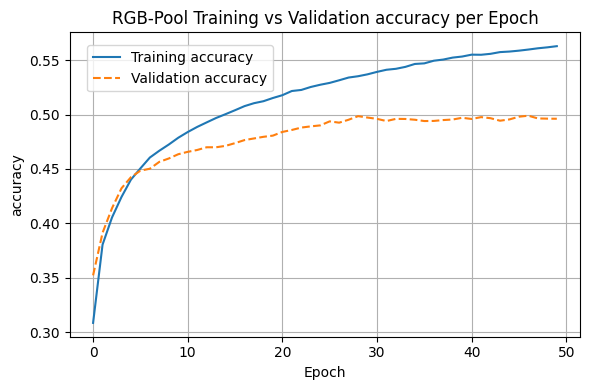

Training model for HSL-OriS...


/Users/chingyu/anaconda3/envs/tf-m4/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


HSL-OriS accuracy: 0.4288
HSL-OriS duration: 184.6808 seconds


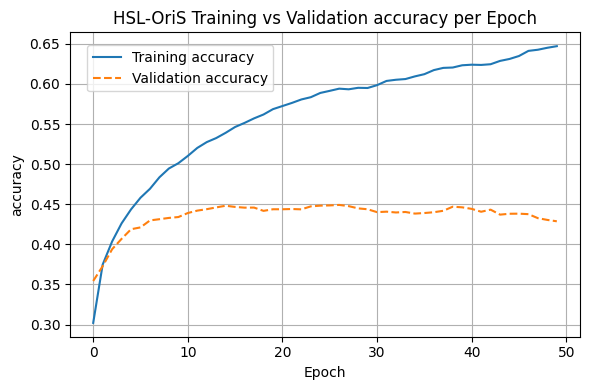

Training model for HSL-Pool...


/Users/chingyu/anaconda3/envs/tf-m4/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


HSL-Pool accuracy: 0.4525
HSL-Pool duration: 328.9528 seconds


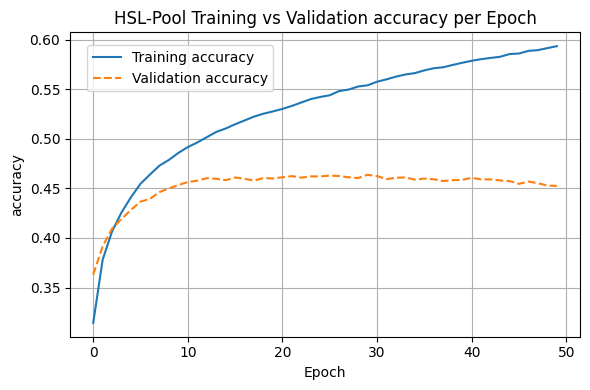

In [53]:
# ---- building model and get info ----
for name, (Xtr, ytr, Xv, yv, act, node1, node2, bats, epoch, Xt) in mlp_parameter.items():
    print(f"Training model for {name}...")
    input_dim = Xtr.shape[1]
    start_time = time.time()
    model, history = train_ensemble_model(name, Xtr, ytr, Xv, yv, input_dim, act, node1, node2, bats, epoch)

    # Predictions and confusion matrix
    preds = model.predict(Xv, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(yv, axis=1)
    acc = accuracy_score(y_true, y_pred)
    dur = time.time() - start_time

    print(f"{name} accuracy: {acc:.4f}")
    print(f"{name} duration: {dur:.4f} seconds")
    plot_training_curves(history, name = name)

### 3-3 Convolutional neural network

In [ ]:
'Random Search'
#Random Search for CNN (NET I Architecture: 32x32x3)
#This version tunes 5 hyperparameters that directly affect bias–variance: L2 regularisation, dropout rate, batch size, number of filters, and learning rate.
#Focused on reducing current overfitting by introducing stronger regularisation and moderate capacity

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

start = time.time()
#instantiate tuner for random search
cnn_tuner = MyTuner(
    build_model,
    objective='val_accuracy',              #target metric for selection
    max_trials=15,                         #number of random combinations
    executions_per_trial=1,                #run each configuration once
    directory='cnn_random_search',
    project_name='net_i_bias_variance_tuning'
)

#launch search on training data only (20% used for validation internally)
cnn_tuner.search(
    X_train_cnn, y_train_cnn,
    epochs=12,                             #short training for exploration
    validation_split=0.2,
    verbose=1
)

#report best hyperparameters found
cnn_best_hp = cnn_tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters (random search):", cnn_best_hp.values)

#retrieve and summarise best model
cnn_best_model = cnn_tuner.get_best_models(1)[0]
cnn_best_model.summary()
print(f"CNN Random Search duration: {time.time() - start:.2f} seconds")

Reloading Tuner from cnn_random_search/net_i_bias_variance_tuning/tuner0.json
Best hyperparameters (random search): {'filters1': 96, 'l2_reg': 1.9167468637105838e-05, 'filters2': 128, 'filters3': 160, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64}


/home/alfonso/ENTER/envs/tfgpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 160)      │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,622,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,930,602 (11.18 MB)

 Trainable params: 2,930,602 (11.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
'Summary table with top 10 results'
#reload tuner and build a summary table of all random-search trials

#recreate the tuner pointing to the saved directory (this reloads the oracle/trials)
cnn_tuner2 = MyTuner(
    build_model,
    objective='val_accuracy',
    max_trials=15,                 #can be any >= original; it won’t rerun past trials
    executions_per_trial=1,
    directory='cnn_random_search',
    project_name='net_i_bias_variance_tuning',
    seed=42,
    overwrite=False
)

#extract trials into a dataframe (add train_time_sec)
records = []
for trial_id, trial in cnn_tuner2.oracle.trials.items():
    row = trial.hyperparameters.values.copy()

    #val accuracy can be stored as trial.score or in metrics
    val_acc = trial.score
    if val_acc is None and hasattr(trial, "metrics"):
        try:
            val_acc = trial.metrics.get_best_value("val_accuracy")
        except Exception:
            val_acc = None
    row["val_accuracy"] = val_acc

    #add training time in seconds if recorded
    tt = None
    if hasattr(trial, "metrics") and "train_time" in trial.metrics.metrics:
        try:
            tt = trial.metrics.get_last_value("train_time")
        except Exception:
            tt = None
    row["train_time_sec"] = tt

    row["trial_id"] = trial_id
    records.append(row)

#build and show table
df = pd.DataFrame(records).sort_values("val_accuracy", ascending=False).reset_index(drop=True)

#Display top 10 results
display(df.head(10))

Reloading Tuner from cnn_random_search/net_i_bias_variance_tuning/tuner0.json


,filters1,l2_reg,filters2,filters3,dropout_rate,learning_rate,batch_size,val_accuracy,train_time_sec,trial_id
0,96,0.000019,128,160,0.3,0.0010,64,0.744000,76.854634,14
1,32,0.000215,128,128,0.4,0.0005,32,0.743375,111.158445,04
2,32,0.000010,64,160,0.4,0.0010,128,0.739375,38.994607,10
3,64,0.000028,64,96,0.5,0.0005,96,0.736125,50.599834,05
4,32,0.000030,64,96,0.4,0.0010,128,0.734750,32.673335,03
5,32,0.000224,64,160,0.4,0.0010,32,0.728000,109.079248,02
6,64,0.000727,96,96,0.4,0.0005,32,0.726125,119.984392,09
7,32,0.000424,64,128,0.4,0.0010,128,0.725875,38.498244,07
8,96,0.000859,96,96,0.4,0.0010,128,0.720375,48.315821,01
9,32,0.000132,64,96,0.4,0.0001,32,0.674625,106.656800,00


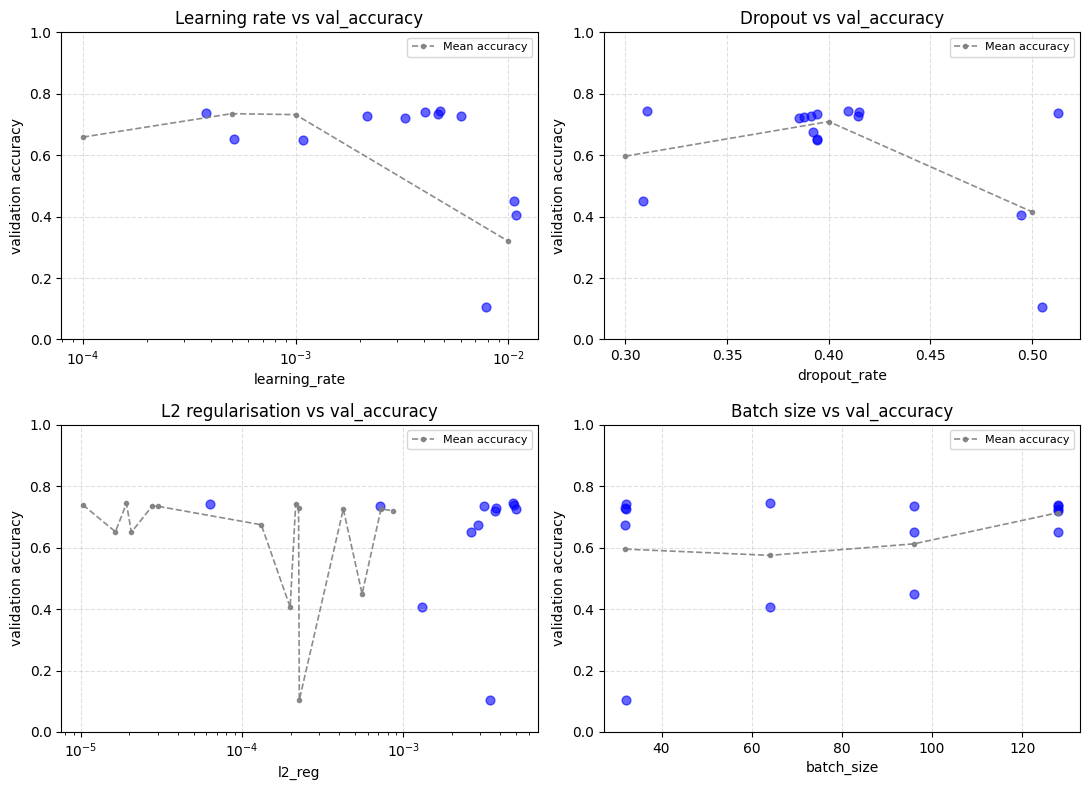

In [ ]:
'2x2 grid of validation-accuracy plots for key hyperparameters'
#Now includes mean trend lines with small dots and thin dashed lines for better readability

#create 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

#top-left: learning rate (log scale)
_plot_param(axes[0, 0], df, "learning_rate", log_x=True, title="Learning rate vs val_accuracy")

#top-right: dropout
_plot_param(axes[0, 1], df, "dropout_rate", log_x=False, title="Dropout vs val_accuracy")

#bottom-left: L2 regularisation (log scale)
_plot_param(axes[1, 0], df, "l2_reg", log_x=True, title="L2 regularisation vs val_accuracy")

#bottom-right: batch size
_plot_param(axes[1, 1], df, "batch_size", log_x=False, title="Batch size vs val_accuracy")

plt.tight_layout()
plt.show()


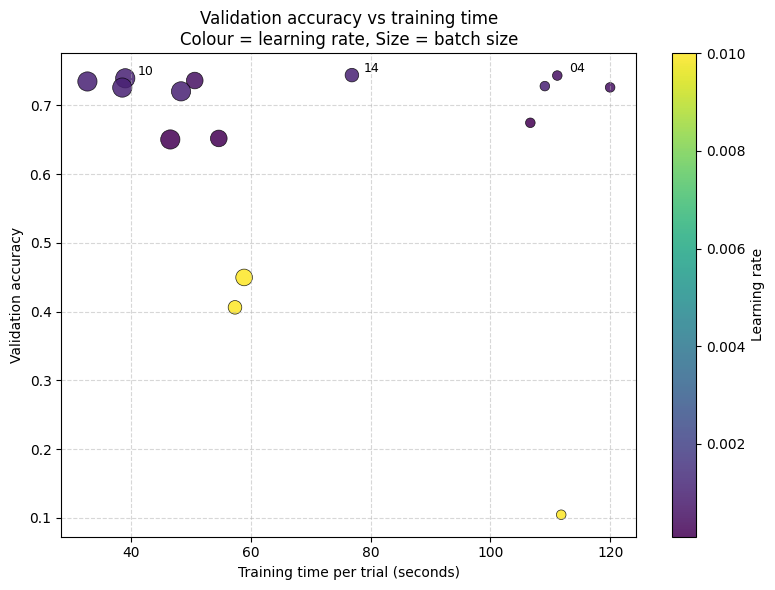

In [ ]:
'scatter plot: training time (seconds) vs validation accuracy'


#filter only trials that have recorded training time
cnn_df_time = df.dropna(subset=['train_time_sec'])

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    cnn_df_time['train_time_sec'],                #x-axis in seconds
    cnn_df_time['val_accuracy'],                  #y-axis accuracy
    s=cnn_df_time['batch_size']*1.5,              #bubble size reflects batch size
    c=cnn_df_time['learning_rate'],               #colour reflects learning rate
    cmap='viridis', alpha=0.85, edgecolors='k', linewidth=0.5
)

#axes and title
plt.xlabel('Training time per trial (seconds)')
plt.ylabel('Validation accuracy')
plt.title('Validation accuracy vs training time\nColour = learning rate, Size = batch size')

#add colourbar for learning rate
cbar = plt.colorbar(scatter)
cbar.set_label('Learning rate')

#annotate top 3 trials
top3 = cnn_df_time.nlargest(3, 'val_accuracy')
for _, row in top3.iterrows():
    plt.text(row['train_time_sec']+2, row['val_accuracy']+0.005, row['trial_id'], fontsize=9)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 4. Final models
In this section, please ensure to include cells to train each model with its best hyperparmater combination independently of the hyperparameter tuning cells, i.e. don't rely on the hyperparameter tuning cells having been run.

### 4-1 Algorithm of choice from first six weeks of course

In [ ]:
# hard-coded chosen hyperparameters
CHOSEN_PCA_VAR = 0.95
CHOSEN_SVM_C = 3

# Final model training & evaluation (independent of the search)
start = time.time()
FIT_ON_TRAIN_PLUS_VAL = True  # set False to train only on the training split

if FIT_ON_TRAIN_PLUS_VAL:
    svm_X_final = np.concatenate([X_train_sklearn_split, X_val_sklearn], axis=0)
    svm_y_final = np.concatenate([y_train_sklearn_split, y_val_sklearn_split], axis=0)
else:
    svm_X_final = X_train_sklearn_split
    svm_y_final = y_train_sklearn_split

svm_final_model = Pipeline([
    ("pca", PCA(n_components=CHOSEN_PCA_VAR, svd_solver="full")),
    ("svm", LinearSVC(C=CHOSEN_SVM_C, dual="auto", max_iter=5000, random_state=42))
])

print("Fitting FINAL model...")
svm_final_model.fit(svm_X_final, svm_y_final)

# keep a validation score for your write-up even if you train on train+val
y_val_pred_final = svm_final_model.predict(X_val_sklearn)
val_acc_final = accuracy_score(y_val_sklearn_split, y_val_pred_final)
print(f"Final model validation accuracy: {val_acc_final:.4f}")
print(f"Final model training duration: {time.time() - start:.2f} seconds")
# Test evaluation
svm_y_test_pred = svm_final_model.predict(X_test_flat)
svm_test_acc = accuracy_score(y_test_sklearn, svm_y_test_pred)
print("Test accuracy: {:.4f}".format(svm_test_acc))


Fitting FINAL model...
Final model validation accuracy: 0.4208
Final model training duration: 34.59 seconds
Test accuracy: 0.4036



Classification report (test):
              precision    recall  f1-score   support

           0     0.4240    0.4850    0.4524      1000
           1     0.4170    0.5050    0.4568      1000
           2     0.3293    0.1920    0.2426      1000
           3     0.3384    0.1990    0.2506      1000
           4     0.4009    0.2550    0.3117      1000
           5     0.3602    0.3260    0.3423      1000
           6     0.3964    0.5760    0.4696      1000
           7     0.4283    0.4570    0.4422      1000
           8     0.4474    0.5610    0.4978      1000
           9     0.4142    0.4800    0.4447      1000

    accuracy                         0.4036     10000
   macro avg     0.3956    0.4036    0.3911     10000
weighted avg     0.3956    0.4036    0.3911     10000



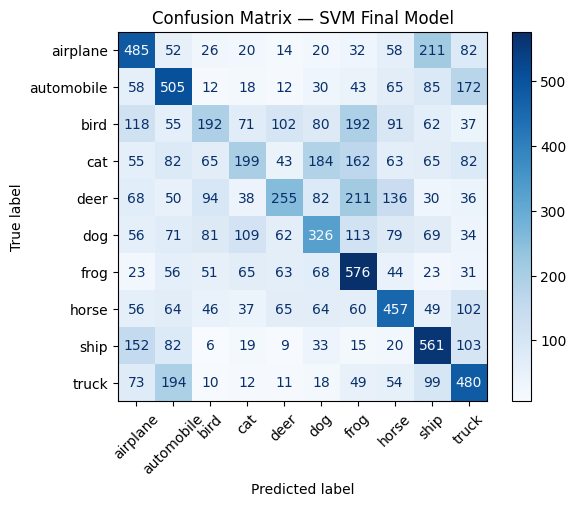

In [75]:
# Reports & confusion matrices for the final model
print("\nClassification report (test):")
print(classification_report(y_test_sklearn, svm_y_test_pred, digits=4))

# Draw SVM CM
cm_svm = confusion_matrix(y_test_sklearn, svm_y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_Names).plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix — SVM Final Model')
plt.show()


### 4-2 Fully connected neural network

In [43]:
final_mlp_param = {
    "RGB-OriS": (X_train_mlp,    y_train_mlp, X_val_mlp,      y_val_mlp, 'leaky_relu',32, 128, 128, 40, X_test_flat), # X test for later use, just save in dict first
    "RGB-Pool": (X_train_rgb_16, y_train_mlp, X_valid_rgb_16, y_val_mlp, 'leaky_relu',32, 128, 128, 50, X_test__rgb_16),
    "HSL-OriS": (X_train_hsl_32, y_train_mlp, X_valid_hsl_32, y_val_mlp, 'leaky_relu',32, 128, 128, 20, X_test__hsl_32),
    "HSL-Pool": (X_train_hsl_16, y_train_mlp, X_valid_hsl_16, y_val_mlp, 'leaky_relu',32, 128, 64, 30, X_test__hsl_16)
}

In [44]:
final_mlp_models = {}  # master dictionary

# ---- building model and get info ----
for name, (Xtr, ytr, Xv, yv, act, node1, node2, bats, epoch, Xt) in final_mlp_param.items():
    print(f"Training model for {name}...")
    input_dim = Xtr.shape[1]
    start = time.time()
    model, history = train_ensemble_model(name, Xtr, ytr, Xv, yv, input_dim, act, node1, node2, bats, epoch)
    duration = time.time() - start

    # Predictions and confusion matrix
    preds = model.predict(Xv, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(yv, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    class_acc_df = pd.DataFrame({
        'Accuracy': class_acc
    })
        # Placeholder (weights will be built later after all models are known)
    final_mlp_models[name] = {
        "model": model,
        "accuracy": acc,
        "cm": cm,
        "duration": duration,
        "class_acc": class_acc,
        "class_acc_df": class_acc_df,
        "class_weights": None,  # added later: calculate after all acc exists
        "history": history,
        "class_report": classification_report(y_true, y_pred, target_names=class_Names),
        "X_test": Xt
    }

    print(f"{name} accuracy: {acc:.4f}")
    print(f"{name} duration: {duration:.2f} seconds")

# ----- after model building and get the acc info ----

class_acc_df = pd.concat(
    {name: model_details["class_acc_df"]["Accuracy"] 
     for name, model_details in final_mlp_models.items()}, axis=1
)

# Assign weights back to each model
class_weights = class_acc_df.div(class_acc_df.sum(axis=1), axis=0).round(2)
for name in final_mlp_models:
    final_mlp_models[name]["class_weights"] = class_weights[name]

print("Class-wise accuracy table:")
print(class_acc_df.round(3))
print("\nNormalised weights:")
print(class_weights)

Training model for RGB-OriS...
RGB-OriS accuracy: 0.4710
RGB-OriS duration: 133.85 seconds
Training model for RGB-Pool...


/Users/chingyu/anaconda3/envs/tf-m4/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RGB-Pool accuracy: 0.4971
RGB-Pool duration: 156.49 seconds
Training model for HSL-OriS...


/Users/chingyu/anaconda3/envs/tf-m4/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


HSL-OriS accuracy: 0.4355
HSL-OriS duration: 64.80 seconds
Training model for HSL-Pool...


/Users/chingyu/anaconda3/envs/tf-m4/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


HSL-Pool accuracy: 0.4568
HSL-Pool duration: 174.44 seconds
Class-wise accuracy table:
   RGB-OriS  RGB-Pool  HSL-OriS  HSL-Pool
0     0.607     0.593     0.545     0.618
1     0.503     0.585     0.515     0.565
2     0.391     0.256     0.353     0.267
3     0.245     0.294     0.328     0.306
4     0.354     0.416     0.277     0.347
5     0.292     0.362     0.229     0.382
6     0.590     0.730     0.572     0.465
7     0.635     0.565     0.414     0.588
8     0.562     0.663     0.656     0.630
9     0.531     0.507     0.466     0.400

Normalised weights:
   RGB-OriS  RGB-Pool  HSL-OriS  HSL-Pool
0      0.26      0.25      0.23      0.26
1      0.23      0.27      0.24      0.26
2      0.31      0.20      0.28      0.21
3      0.21      0.25      0.28      0.26
4      0.25      0.30      0.20      0.25
5      0.23      0.29      0.18      0.30
6      0.25      0.31      0.24      0.20
7      0.29      0.26      0.19      0.27
8      0.22      0.26      0.26      0.25
9      0.2

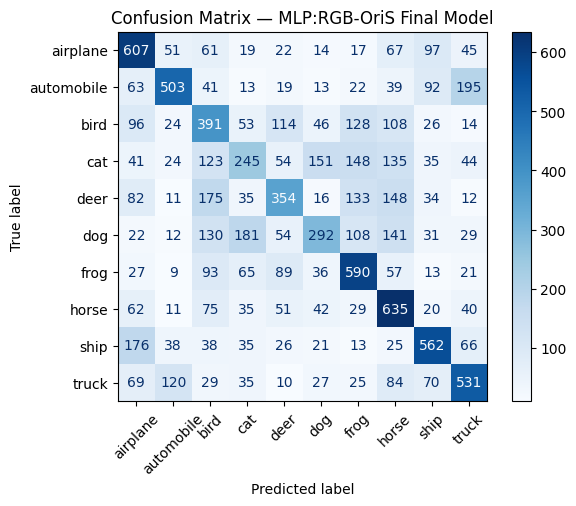

              precision    recall  f1-score   support

    airplane       0.49      0.61      0.54      1000
  automobile       0.63      0.50      0.56      1000
        bird       0.34      0.39      0.36      1000
         cat       0.34      0.24      0.29      1000
        deer       0.45      0.35      0.39      1000
         dog       0.44      0.29      0.35      1000
        frog       0.49      0.59      0.53      1000
       horse       0.44      0.64      0.52      1000
        ship       0.57      0.56      0.57      1000
       truck       0.53      0.53      0.53      1000

    accuracy                           0.47     10000
   macro avg       0.47      0.47      0.46     10000
weighted avg       0.47      0.47      0.46     10000



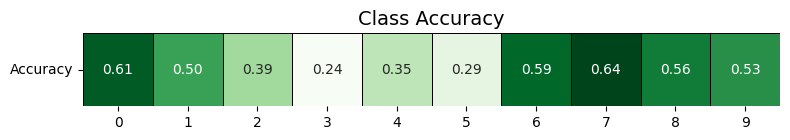

RGB-OriS Test Accuracy: 0.488
RGB-OriS Training Duration: 133.85 seconds


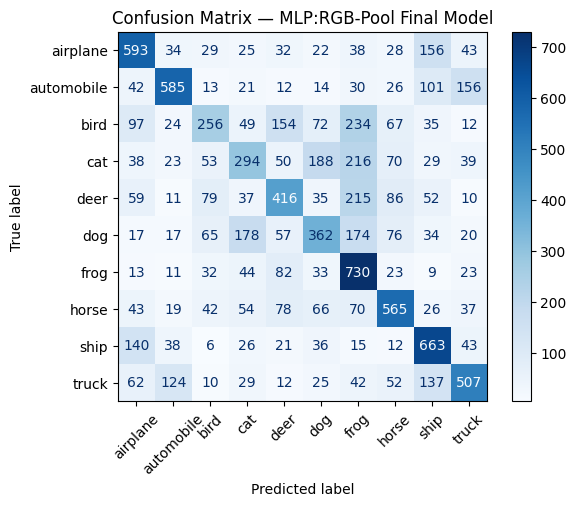

              precision    recall  f1-score   support

    airplane       0.54      0.59      0.56      1000
  automobile       0.66      0.58      0.62      1000
        bird       0.44      0.26      0.32      1000
         cat       0.39      0.29      0.33      1000
        deer       0.46      0.42      0.43      1000
         dog       0.42      0.36      0.39      1000
        frog       0.41      0.73      0.53      1000
       horse       0.56      0.56      0.56      1000
        ship       0.53      0.66      0.59      1000
       truck       0.57      0.51      0.54      1000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.49     10000



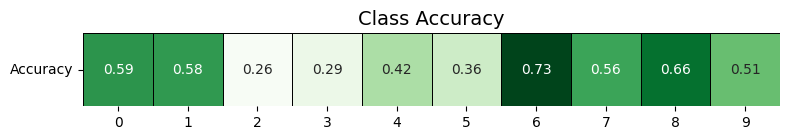

RGB-Pool Test Accuracy: 0.501
RGB-Pool Training Duration: 156.49 seconds


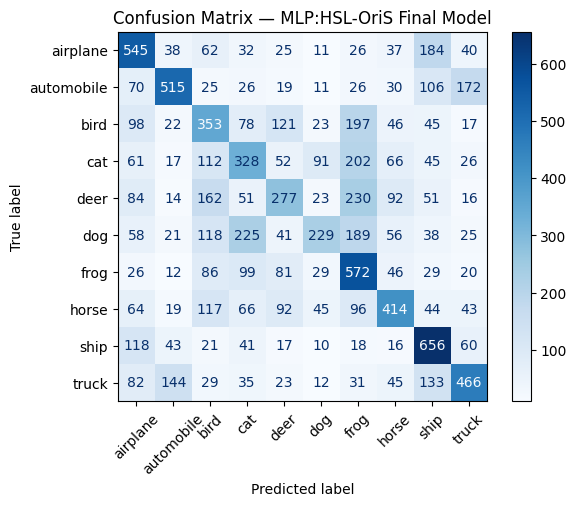

              precision    recall  f1-score   support

    airplane       0.45      0.55      0.49      1000
  automobile       0.61      0.52      0.56      1000
        bird       0.33      0.35      0.34      1000
         cat       0.33      0.33      0.33      1000
        deer       0.37      0.28      0.32      1000
         dog       0.47      0.23      0.31      1000
        frog       0.36      0.57      0.44      1000
       horse       0.49      0.41      0.45      1000
        ship       0.49      0.66      0.56      1000
       truck       0.53      0.47      0.49      1000

    accuracy                           0.44     10000
   macro avg       0.44      0.44      0.43     10000
weighted avg       0.44      0.44      0.43     10000



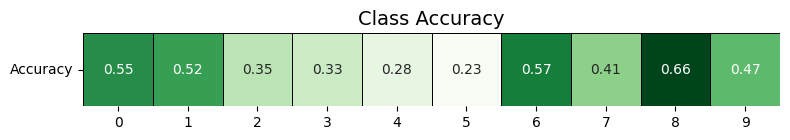

HSL-OriS Test Accuracy: 0.441
HSL-OriS Training Duration: 64.80 seconds


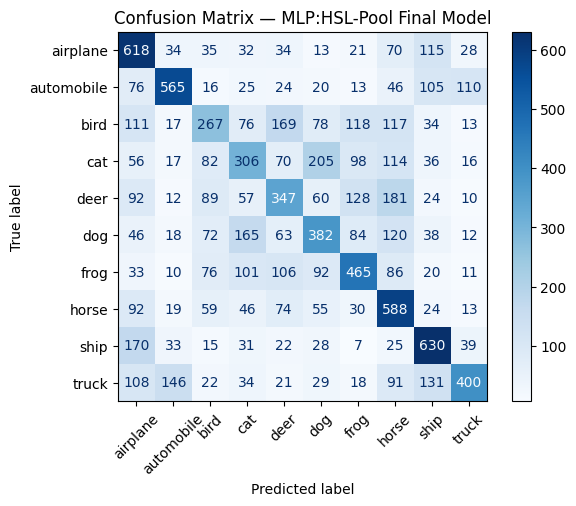

              precision    recall  f1-score   support

    airplane       0.44      0.62      0.51      1000
  automobile       0.65      0.56      0.60      1000
        bird       0.36      0.27      0.31      1000
         cat       0.35      0.31      0.33      1000
        deer       0.37      0.35      0.36      1000
         dog       0.40      0.38      0.39      1000
        frog       0.47      0.47      0.47      1000
       horse       0.41      0.59      0.48      1000
        ship       0.54      0.63      0.58      1000
       truck       0.61      0.40      0.48      1000

    accuracy                           0.46     10000
   macro avg       0.46      0.46      0.45     10000
weighted avg       0.46      0.46      0.45     10000



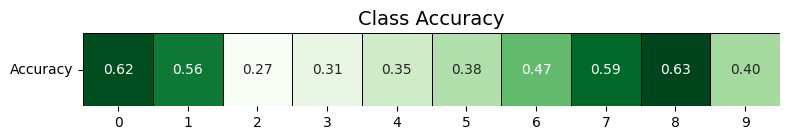

HSL-Pool Test Accuracy: 0.466
HSL-Pool Training Duration: 174.44 seconds


In [45]:
### Result for each input config
for name, model_details in final_mlp_models.items():
    ConfusionMatrixDisplay(confusion_matrix=model_details['cm'], display_labels=class_Names).plot(cmap='Blues', xticks_rotation=45)
    plt.title(f'Confusion Matrix — MLP:{name} Final Model')
    plt.show()
    print(model_details['class_report'])
    plot_percent_heatmap(model_details['class_acc_df'].transpose(), 'Class Accuracy', cmap='Greens', figsize=(8,1.5),linew=0.5)
                        
    model = model_details['model']
    X = model_details["X_test"]
    #prediction
    mlp_y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    mlp_acc = accuracy_score(y_test, mlp_y_pred)
    print(f"{name} Test Accuracy: {mlp_acc:.3f}")
    print(f"{name} Training Duration: {model_details['duration']:.2f} seconds")

In [53]:
type(model_details['class_weights'])

pandas.core.series.Series

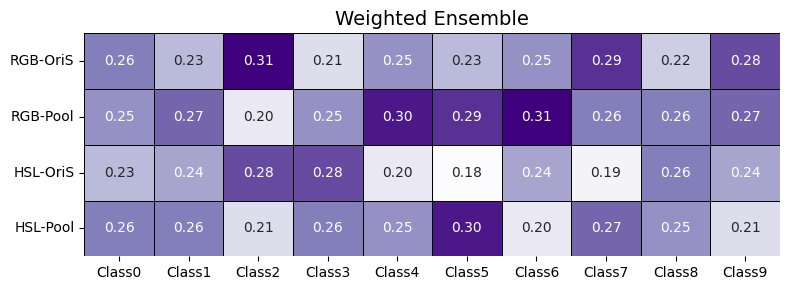

class,Class0,Class1,Class2,Class3,Class4,Class5,Class6,Class7,Class8,Class9
RGB-OriS,0.26,0.23,0.31,0.21,0.25,0.23,0.25,0.29,0.22,0.28
RGB-Pool,0.25,0.27,0.20,0.25,0.30,0.29,0.31,0.26,0.26,0.27
HSL-OriS,0.23,0.24,0.28,0.28,0.20,0.18,0.24,0.19,0.26,0.24
HSL-Pool,0.26,0.26,0.21,0.26,0.25,0.30,0.20,0.27,0.25,0.21


In [66]:
### MLP input comparison
mlp_class_weights = pd.DataFrame({
    name: model_details['class_weights']
    for name, model_details in final_mlp_models.items()
})

mlp_class_weights['class'] = 'Class' + mlp_class_weights.index.astype(str)
mlp_class_weights = mlp_class_weights.set_index('class')

plot_percent_heatmap(mlp_class_weights.transpose(), 'Weighted Ensemble', cmap='Purples', figsize=(8,3),linew=0.5)

Weighted Ensemble Accuracy: 0.5349


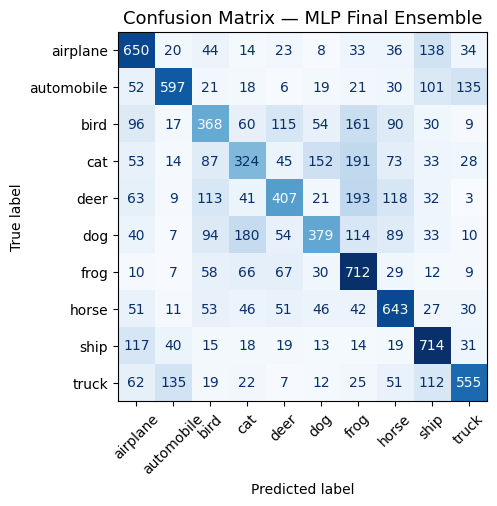

              precision    recall  f1-score   support

    airplane       0.54      0.65      0.59      1000
  automobile       0.70      0.60      0.64      1000
        bird       0.42      0.37      0.39      1000
         cat       0.41      0.32      0.36      1000
        deer       0.51      0.41      0.45      1000
         dog       0.52      0.38      0.44      1000
        frog       0.47      0.71      0.57      1000
       horse       0.55      0.64      0.59      1000
        ship       0.58      0.71      0.64      1000
       truck       0.66      0.56      0.60      1000

    accuracy                           0.53     10000
   macro avg       0.54      0.53      0.53     10000
weighted avg       0.54      0.53      0.53     10000



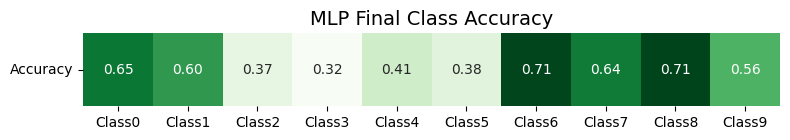

,Class0,Class1,Class2,Class3,Class4,Class5,Class6,Class7,Class8,Class9
Accuracy,0.65,0.597,0.368,0.324,0.407,0.379,0.712,0.643,0.714,0.555


In [47]:
### MLP Final ensembler

y_pred_mlp_mix = ensemble_predict_weighted(final_mlp_models)
y_true = np.argmax(y_test_nn, axis=1)

# --- Overall accuracy ---
mlp_final_accuracy = accuracy_score(y_true, y_pred_mlp_mix)
print(f"Weighted Ensemble Accuracy: {mlp_final_accuracy:.4f}")

# --- Confusion matrix ---
mlp_final_cm = confusion_matrix(y_true, y_pred_mlp_mix)
mlp_cm_df = pd.DataFrame(
    mlp_final_cm,
    index=[f"T{i}" for i in range(10)],
    columns=[f"P{i}" for i in range(10)]
)

# --- Per-class accuracy (row-wise: recall per class) ---
pred_class_acc = np.diag(mlp_cm_df) / mlp_cm_df.sum(axis=1)
pred_class_acc_df = pred_class_acc.to_frame(name="Accuracy")
pred_class_acc_df.index = [f"Class{i}" for i in range(10)]

# --- Plot confusion matrix ---
ConfusionMatrixDisplay(confusion_matrix=mlp_final_cm, display_labels=class_Names).plot(
    cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix — MLP Final Ensemble', fontsize=13)
plt.show()

print(classification_report(y_true, y_pred_mlp_mix, target_names=class_Names))
plot_percent_heatmap(pred_class_acc_df.transpose(), 'MLP Final Class Accuracy', cmap='Greens', figsize=(8,1.5))



### 4-3 CNN

In [ ]:
'CNN Final model'

#best hyperparameters from random search
start = time.time()
best_l2 = 1.9167468637105838e-05   #≈1.9e-5
best_dropout = 0.3
best_lr = 0.001
best_batch = 64

#build CNN model
final_cnn_model = Sequential([
    #Input: 32x32x3 RGB
    #Conv block 1
    Conv2D(
        96, (3, 3),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(best_l2),
        input_shape=(32, 32, 3)
    ),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    #Conv block 2
    Conv2D(
        128, (3, 3),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(best_l2)
    ),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    #Conv block 3
    Conv2D(
        160, (3, 3),                  #updated to 160 filters
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(best_l2)
    ),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    #Flatten + regularised dense head
    Flatten(),
    Dropout(best_dropout),            #dropout to reduce variance/overfitting
    Dense(
        1024,
        activation='relu',
        kernel_regularizer=regularizers.l2(best_l2)
    ),
    Dense(10, activation='softmax')   #10 CIFAR-10 classes
])

#compile model
final_cnn_model.compile(
    optimizer=Adam(learning_rate=best_lr),   #learning rate from best trial
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#display model summary
final_cnn_model.summary()

#train model using training and validation sets (not test set)
cnn_history = final_cnn_model.fit(
    X_train_cnn, y_train_cnn,                 #training set (one-hot labels)
    batch_size=best_batch,                    #batch size from best trial
    epochs=20,
    validation_data=(X_val_cnn, y_val_cnn),   #validation set
    verbose=1
)

#evaluate model once on the test set after training
test_loss, test_acc = final_cnn_model.evaluate(X_test_processed, y_test_nn, verbose=1)
print(f"Final test accuracy: {test_acc:.4f}")
print(f"Final test loss: {test_loss:.4f}")
print(f"Final CNN duration: {time.time() - start:.2f} seconds")


/home/alfonso/ENTER/envs/tfgpu/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 160)      │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1024)           │     2,622,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,930,602 (11.18 MB)

 Trainable params: 2,930,602 (11.18 MB)

...

620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3509 - loss: 1.7847

2025-10-23 21:43:02.335485: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_173', 1232 bytes spill stores, 1180 bytes spill loads



625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.4527 - loss: 1.5240 - val_accuracy: 0.5799 - val_loss: 1.2021
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6123 - loss: 1.1166 - val_accuracy: 0.6616 - val_loss: 0.9969
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6783 - loss: 0.9506 - val_accuracy: 0.6858 - val_loss: 0.9557
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7250 - loss: 0.8328 - val_accuracy: 0.6922 - val_loss: 0.9579
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7609 - loss: 0.7430 - val_accuracy: 0.7190 - val_loss: 0.8924
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7869 - loss: 0.6733 - val_accuracy: 0.7351 - val_loss: 0.8811
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8142 - loss: 0.6097 - val_accuracy: 0.7408 - val_loss: 0.8821
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8334 - loss: 0.5630 - val_accuracy: 0.7395 - va

2025-10-23 21:44:32.046214: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_180', 4 bytes spill stores, 4 bytes spill loads

2025-10-23 21:44:32.151083: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_180', 16 bytes spill stores, 16 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7436 - loss: 1.2402
Final test accuracy: 0.7436
Final test loss: 1.2402


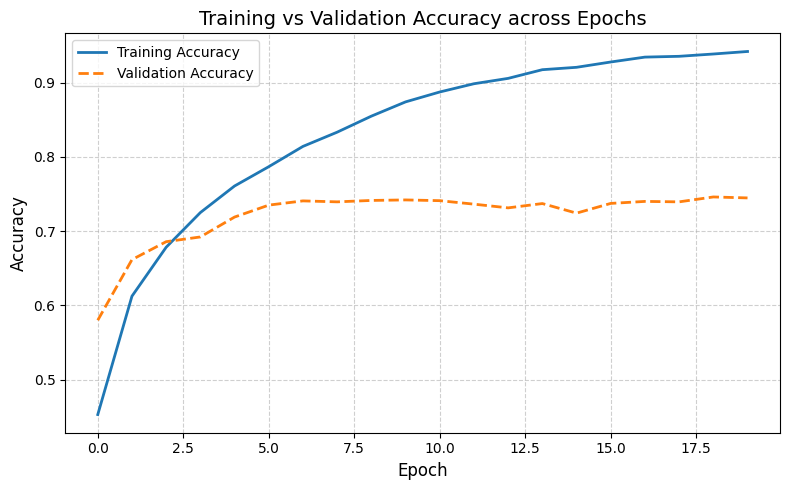

In [ ]:
'Accuracy vs Validation Accuracy Plot'
#This visualisation compares the model’s performance on training and validation data
plot_training_curves(cnn_history, name = 'CNN', setylim=False, figsize=(8, 5))


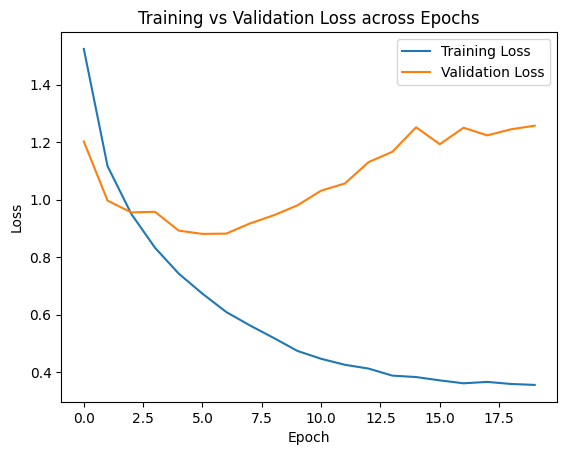

In [ ]:
"progression and convergence analysis"
plot_training_curves(cnn_history, metric = 'loss', name = 'CNN', setylim=False, figsize=(8, 5), secline = '-')


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


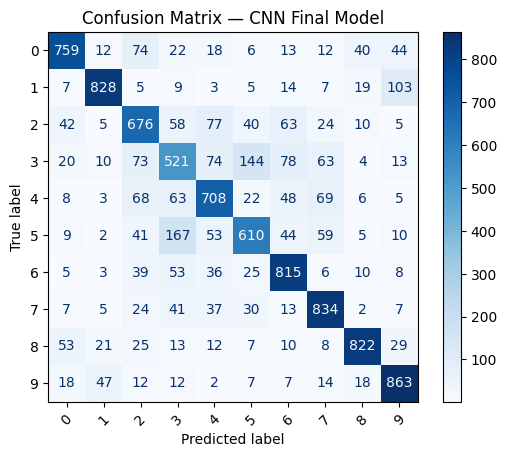

In [ ]:
"confusion matirx"

cnn_y_pred = np.argmax(final_cnn_model.predict(X_test_processed), axis=1)
cnn_y_true = np.argmax(y_test_nn, axis=1)

cnn_cm = confusion_matrix(cnn_y_true, cnn_y_pred)
ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=class_Names).plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix — CNN Final Model')
plt.show()


In [ ]:
"Classification report (precision, recall, F1-score)"

print(classification_report(cnn_y_true, cnn_y_pred, target_names=class_Names))

              precision    recall  f1-score   support

           0     0.8179    0.7590    0.7873      1000
           1     0.8846    0.8280    0.8554      1000
           2     0.6519    0.6760    0.6637      1000
           3     0.5433    0.5210    0.5319      1000
           4     0.6941    0.7080    0.7010      1000
           5     0.6808    0.6100    0.6435      1000
           6     0.7376    0.8150    0.7743      1000
           7     0.7609    0.8340    0.7958      1000
           8     0.8782    0.8220    0.8492      1000
           9     0.7939    0.8630    0.8270      1000

    accuracy                         0.7436     10000
   macro avg     0.7443    0.7436    0.7429     10000
weighted avg     0.7443    0.7436    0.7429     10000



In [ ]:
"ROC curve"
roc_auc = roc_auc_score(y_test_nn, final_cnn_model.predict(X_test_processed), multi_class='ovr')
print(f"Macro-Averaged ROC-AUC: {roc_auc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Macro-Averaged ROC-AUC: 0.962


## 5. Graphs

### 5-1 Algorithm of choice from first six weeks of course

In [76]:
# === CV results: tidy table ===
assert 'svm_search' in globals(), "Run the GridSearchCV cell first (it must define `svm_search`)."

cvdf = pd.DataFrame(svm_search.cv_results_).copy()
cvdf['pca_var_target'] = cvdf['param_pca__n_components'].astype(float)
cvdf['svm_C']          = cvdf['param_svm__C'].astype(float)

cols = [
    "rank_test_score","mean_test_score","std_test_score",
    "mean_fit_time","std_fit_time","mean_score_time","std_score_time",
    "pca_var_target","svm_C"
]
svm_cv_summary = (cvdf[cols]
           .sort_values("rank_test_score", ascending=True)
           .rename(columns={
               "mean_test_score":"cv_mean_acc",
               "std_test_score":"cv_std_acc",
               "mean_fit_time":"fit_time_s",
               "mean_score_time":"score_time_s"
           }))

print("Top 10 CV configs:")
display(svm_cv_summary.head(10))

# Save a copy for your report folder
Path("figs").mkdir(exist_ok=True)
svm_cv_summary.to_csv("figs/pcasvm_cv_summary.csv", index=False)
print("Saved: figs/pcasvm_cv_summary.csv")


Top 10 CV configs:


,rank_test_score,cv_mean_acc,cv_std_acc,fit_time_s,std_fit_time,score_time_s,std_score_time,pca_var_target,svm_C
16,1,0.401275,0.003107,74.052178,2.578171,2.314112,1.363317,0.95,5.00
17,2,0.401250,0.003076,79.870968,3.424486,1.620520,0.217591,0.95,10.00
15,2,0.401250,0.003108,76.467501,4.071557,1.969135,0.938708,0.95,1.00
14,2,0.401250,0.003108,81.558202,1.623800,1.241054,0.023435,0.95,0.50
13,5,0.401200,0.003113,91.091028,8.367517,2.311501,1.717374,0.95,0.10
12,6,0.401025,0.003231,106.822468,2.106895,1.646907,0.160291,0.95,0.05
18,7,0.391025,0.001716,205.600956,4.230262,2.896020,0.154282,0.99,0.05
19,8,0.389775,0.001785,211.499100,4.849016,3.607386,0.420061,0.99,0.10
20,9,0.388875,0.002195,210.529524,2.473754,2.860205,0.123939,0.99,0.50
21,10,0.388550,0.001928,184.086572,15.879160,2.335368,0.204395,0.99,1.00


Saved: figs/pcasvm_cv_summary.csv


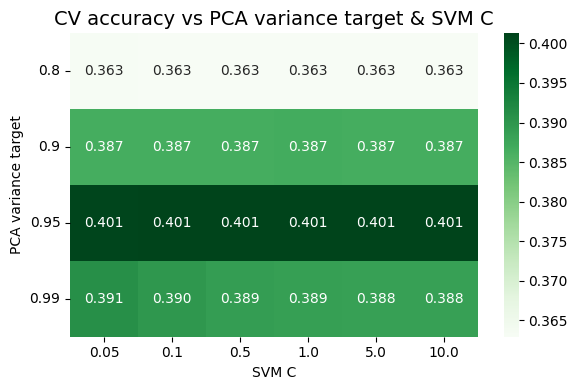

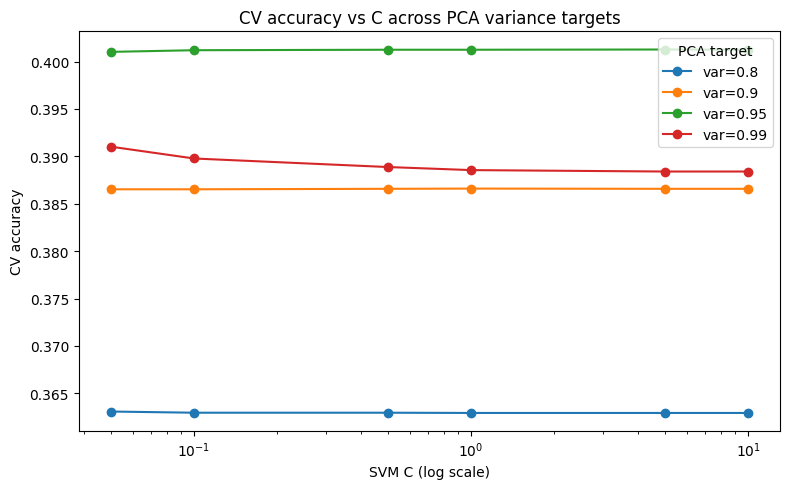

In [77]:
# === Accuracy heatmap & line plots ===

# Heatmap of CV accuracy
plot_percent_heatmap(
    df=svm_cv_summary,
    title="CV accuracy vs PCA variance target & SVM C",
    cmap="Greens",
    pivot_by=["pca_var_target", "svm_C","cv_mean_acc"],
    fmt=".3f",
    XYlabel=["SVM C","PCA variance target"],
    cbar=True
)

# Line plots: accuracy vs C for each PCA variance target
acc_pivot = (svm_cv_summary
             .pivot(index="pca_var_target", columns="svm_C", values="cv_mean_acc")
             .sort_index(ascending=True))
plt.figure(figsize=(8,5))
for v in sorted(acc_pivot.index):
    xs = acc_pivot.columns.values
    ys = acc_pivot.loc[v, :].values
    plt.plot(xs, ys, marker="o", label=f"var={v}")
plt.xscale("log")
plt.xlabel("SVM C (log scale)"); plt.ylabel("CV accuracy")
plt.title("CV accuracy vs C across PCA variance targets")
plt.legend(title="PCA target"); plt.tight_layout()
plt.savefig("figs/pcasvm_cv_acc_lines.png", dpi=200); plt.show()


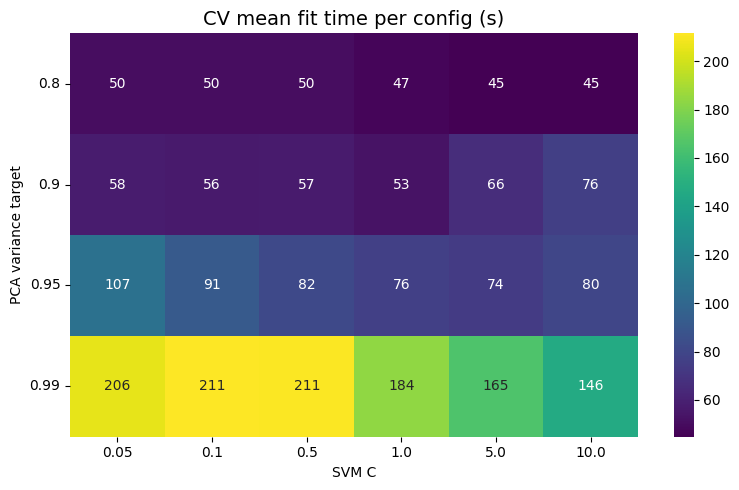

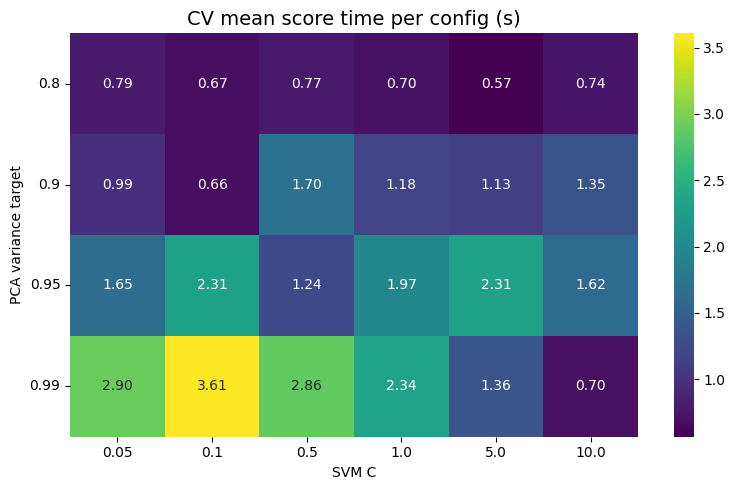

svm_C,0.05,0.10,0.50,1.00,5.00,10.00
pca_var_target,,,,,,
0.80,0.786037,0.666388,0.774108,0.697507,0.566107,0.738430
0.90,0.987452,0.663005,1.698154,1.181424,1.125345,1.345976
0.95,1.646907,2.311501,1.241054,1.969135,2.314112,1.620520
0.99,2.896020,3.607386,2.860205,2.335368,1.362254,0.696508


In [78]:
assert 'X_train_sklearn_split' in globals(), "Need X_train_sklearn_split to estimate k."

plot_percent_heatmap(
    svm_cv_summary,
    title="CV mean fit time per config (s)",
    pivot_by=["pca_var_target", "svm_C","fit_time_s"],
    figsize=(8,5),
    cmap="viridis",
    fmt=".0f",
    XYlabel=["SVM C","PCA variance target"],
    cbar=True
)

plot_percent_heatmap(
    svm_cv_summary,
    title="CV mean score time per config (s)",
    pivot_by=["pca_var_target", "svm_C","score_time_s"],
    figsize=(8,5),
    cmap="viridis",
    fmt=".2f",
    XYlabel=["SVM C","PCA variance target"],
    cbar=True
)


In [79]:
assert 'X_train_sklearn_split' in globals(), "Need X_train_sklearn_split to estimate k."

var_targets = sorted(svm_cv_summary['pca_var_target'].unique())
k_by_var = []
for v in var_targets:
    p = PCA(n_components=v, svd_solver="full").fit(X_train_sklearn_split)
    k_by_var.append(p.n_components_)

k_table = pd.DataFrame({"pca_var_target": var_targets, "k_components": k_by_var})
display(k_table)

,pca_var_target,k_components
0,0.80,33
1,0.90,99
2,0.95,216
3,0.99,656


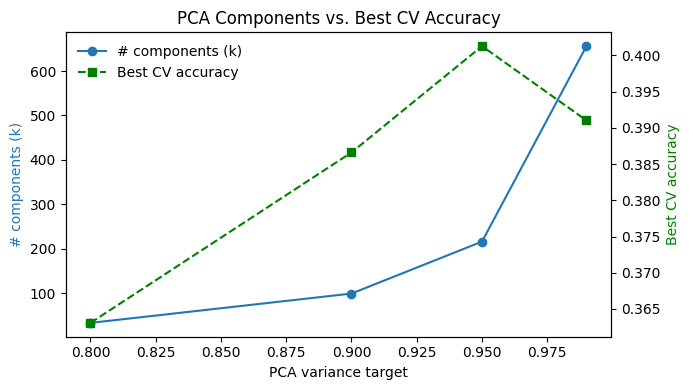

In [80]:
# === Map "variance target" → actual number of components k (train split only) ===

merged = plot_pca_components_vs_accuracy(
    k_table=k_table,
    svm_cv_summary=svm_cv_summary,
    var_col="pca_var_target",
    comp_col="k_components",
    acc_col="cv_mean_acc",
    title="PCA Components vs. Best CV Accuracy",
    save_path="figs/pcasvm_k_vs_acc.png"
)


,class,precision,recall,f1-score
0,airplane,0.423951,0.485,0.452425
1,automobile,0.417011,0.505,0.456807
2,bird,0.329331,0.192,0.242577
3,cat,0.338435,0.199,0.250630
4,deer,0.400943,0.255,0.311736
5,dog,0.360221,0.326,0.342257
6,frog,0.396421,0.576,0.469629
7,horse,0.428304,0.457,0.442187
8,ship,0.447368,0.561,0.497782
9,truck,0.414150,0.480,0.444650


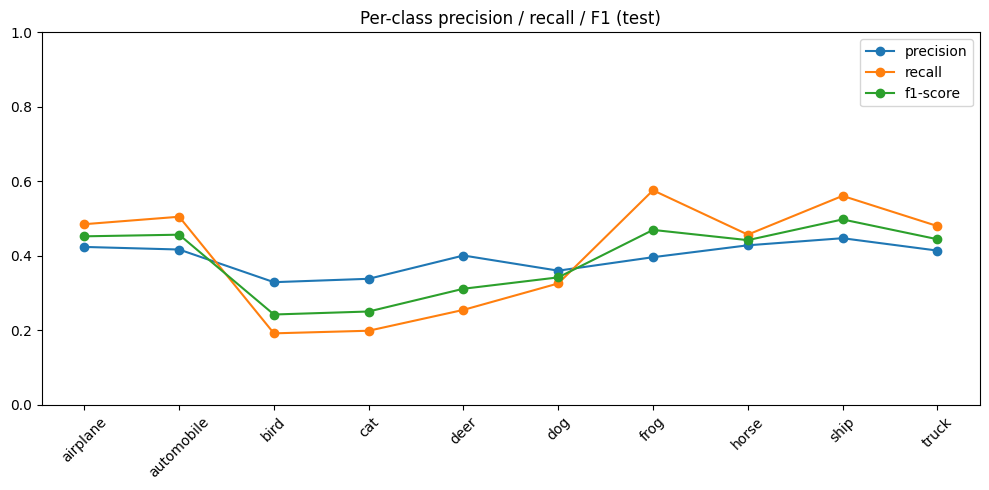

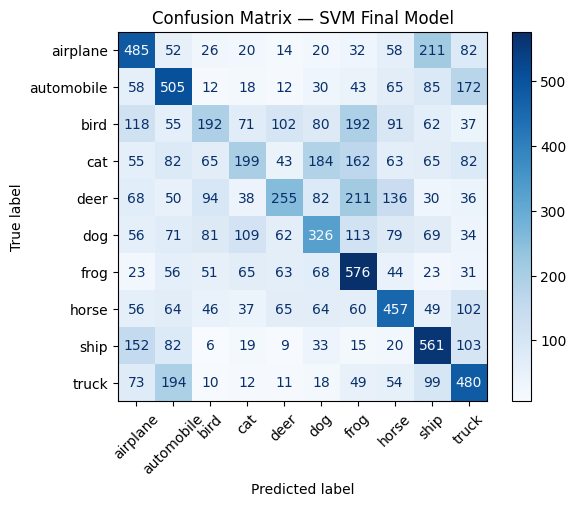

In [81]:
# === Per-class precision/recall/F1 and enriched normalized confusion matrix (test) ===

assert 'svm_y_test_pred' in globals() and 'y_test_sklearn' in globals(), "Run the final model cell first."

# ---------- Per-class table (same as before) ----------
rep = classification_report(y_test_sklearn, svm_y_test_pred, target_names=class_Names, output_dict=True)
per_class = (pd.DataFrame(rep).T
             .iloc[:len(class_Names), :][["precision", "recall", "f1-score"]]
             .reset_index().rename(columns={"index": "class"}))
display(per_class)

# Line plot (precision/recall/F1)
plt.figure(figsize=(10,5))
for metric in ["precision","recall","f1-score"]:
    plt.plot(per_class["class"], per_class[metric], marker="o", label=metric)
plt.xticks(rotation=45); plt.ylim(0,1)
plt.title("Per-class precision / recall / F1 (test)")
plt.legend(); plt.tight_layout()
plt.savefig("figs/pcasvm_per_class_metrics.png", dpi=200); plt.show()

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_sklearn, svm_y_test_pred), display_labels=class_Names).plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix — SVM Final Model')
plt.show()


Top confusions (rate within true class):


,true_class,predicted_as,rate
0,airplane,ship,0.211
1,deer,frog,0.211
2,truck,automobile,0.194
3,bird,frog,0.192
4,cat,dog,0.184


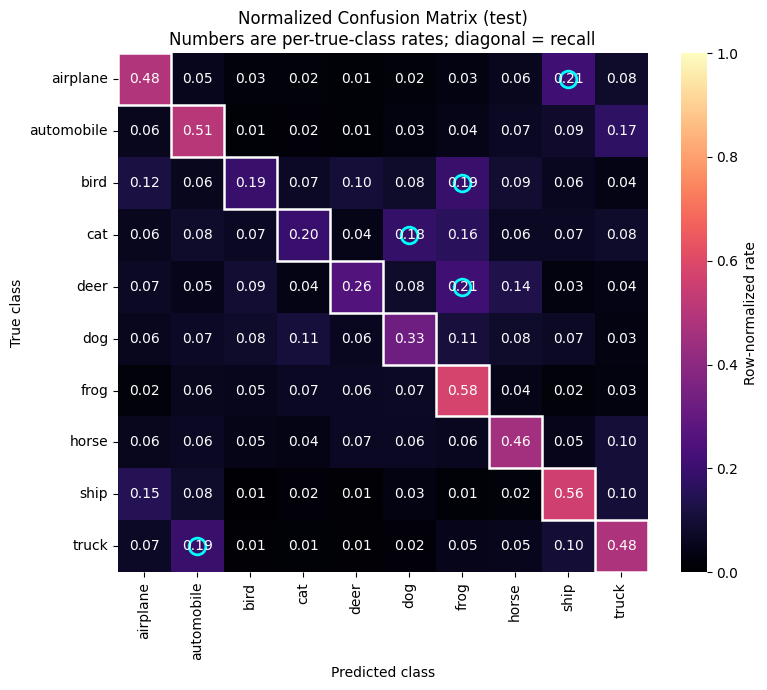

In [82]:
'SVM Special Confusion Matrix'

# ---------- Normalized confusion matrix with richer annotations ----------
svm_cm = confusion_matrix(y_test_sklearn, svm_y_test_pred, normalize="true")
# Top-5 off-diagonal confusions
cm_offdiag = svm_cm.copy()
np.fill_diagonal(cm_offdiag, 0.0)
pairs = []
for i_true in range(len(class_Names)):
    for j_pred in range(len(class_Names)):
        if i_true != j_pred:
            pairs.append((class_Names[i_true], class_Names[j_pred], cm_offdiag[i_true, j_pred]))
top5 = sorted(pairs, key=lambda x: x[2], reverse=True)[:5]
top5_df = pd.DataFrame(top5, columns=["true_class","predicted_as","rate"])
print("Top confusions (rate within true class):")
display(top5_df)
top5_df.to_csv("figs/pcasvm_top_confusions.csv", index=False)

# Grouped recall (vehicles vs animals) to add context
vehicles = ["airplane","automobile","truck","ship","horse"]
animals  = ["bird","cat","deer","dog","frog"]
idx = {c:i for i,c in enumerate(class_Names)}
veh_recall = np.mean([svm_cm[idx[c], idx[c]] for c in vehicles])
ani_recall = np.mean([svm_cm[idx[c], idx[c]] for c in animals])

# Plot
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(
    svm_cm, ax=ax, cmap="magma", vmin=0, vmax=1, annot=True, fmt=".2f",
    xticklabels=class_Names, yticklabels=class_Names,
    cbar_kws={"label": "Row-normalized rate"}
)
ax.set_title("Normalized Confusion Matrix (test)\nNumbers are per-true-class rates; diagonal = recall")
ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")

# Outline diagonal cells (highlights per-class recall)
for i in range(len(class_Names)):
    ax.add_patch(Rectangle((i, i), 1, 1, fill=False, edgecolor="white", linewidth=1.8))

# Highlight top-5 off-diagonal confusions with a cyan ring
for (true_c, pred_c, val) in top5:
    i, j = idx[true_c], idx[pred_c]
    ax.plot(j + 0.5, i + 0.5, marker="o", markersize=12,
            fillstyle="none", markeredgecolor="cyan", markeredgewidth=2)

plt.tight_layout()
plt.savefig("figs/pcasvm_confusion_norm_enriched.png", dpi=200, bbox_inches="tight")
plt.show()